In [1]:
import pandas as pd
import numpy as np

# **Nivel 1: EDA, ESTRUCTURA Y LIMPIEZA BÁSICA**
## **Ejercicio 1: Exploración inicial del Dataset**

Lo primero de todo, cargaremos el archivos como un dataframe para poder visualizar los datos de una manera más eficaz y ver cuáles son los posibles errores y poder analizar sus dimensiones.

Cargamos el archivo excel que tenemos.

In [2]:
from google.colab import files

uploaded = files.upload()

df_trabajadores = pd.read_excel(list(uploaded.keys())[0])

Saving trabajadores.xlsx to trabajadores (1).xlsx


Comprobamos que se ha subido correctamente y lo mostramos. Con esta visualización podremos investigas algunos de los fallos/errores a primera vista.

Lo primero que identifico es que el archivo excel debe tener varias filas en blanco en la parte superior por lo que no lee bien las columnas del dataset.

La fila con índice 3 debería ser la primera/cabecera que nombra las columnas y datos.

Por otro lado, puedo identificar en un promer vistazo que la letra *Ñ* o los *acentos agudos* no se leen correctamente y añade caracteres extraños que dificultan la comprensión.

In [3]:
display(df_trabajadores)

,Dades de l'enquesta de treballadors 2025,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,Generades aleatòriament per seguretat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
3,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
4,1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,1002,Alba,MuÃ±oz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409 â‚¬",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7
1006,1003,Claudia,Gil Ferrer,55297384F,Espanya,ValÃ¨ncia,1.0,11.0,1981.0,H,1.789 â‚¬,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
1007,1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
1008,1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Para poder responder a las siguientes preguntas y poder analizar correctamente los resultados debo subir correctamente el archivo, eliminando las 3 primeras filas en blanco que hacen desplazar la cabecera del dataset.

In [4]:
# Saltamos las 3 primeras filas (título, subtítulo y fila en blanco)
# La fila con índice 3 del Excel es la cabecera real
df_trabajadores = pd.read_excel("trabajadores.xlsx", header=3)

df_trabajadores.head()

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
3,3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1


**» ¿Cuántas filas y columnas tiene el conjunto de datos?**

In [5]:
filas, columnas = df_trabajadores.shape

print(f"El conjunto de datos tiene {filas} filas y {columnas} columnas.")

El conjunto de datos tiene 1007 filas y 20 columnas.


Podemos ver que el dataset tiene un total de 1010 filas y 20 columnas.

**» ¿Qué tipo de datos contiene cada columna?**

In [6]:
print(df_trabajadores.dtypes)

Unnamed: 0                      int64
Nom                            object
Cognoms                        object
DNI                            object
País d'origen                  object
Ciutat                         object
Dia de Naixement              float64
Mes de Naixement              float64
Any de Naixement              float64
Gènere                         object
Salari mensual                 object
Fills                          object
No Fills                       object
Grup Professional              object
CÃ rrec                        object
Nombre_fills                  float64
Te_cotxe                       object
Km_anuals                     float64
Consum_mitja_L_100km          float64
Temperatura_mitjana_ciutat    float64
dtype: object


Como ya hemos establecido la cabecera real del dataset, podemos ver que tenemos distintos tipos de datos según la columna: decimales, números enteros y muchos *object* que no nos permite aclarar si son string, boleanos, etc.

**» ¿Hay alguna fila duplicada?**

In [7]:
duplicadas = df_trabajadores.duplicated().sum()

print(f"Número de filas duplicadas: {duplicadas}")

Número de filas duplicadas: 0


No tenemos filas duplicadas al 100%, puede que haya valores duplicados o incluso DNI que deberían ser únicos. Pero sólo cuando todos los campos de las filas son iguales consideraremos que la fila es duplicada.


---

¡IMPORTANTE!

**Esta respuesta no es 100% correcta**, puesto que la primera columna "*Unnamed 0*" debería ser el ***Index***. El índice es una valor único que nunca debería estar repetido. Como ahora mismo nos piden **no modificar el dataset**, el resultado a la pregunta es 0 filas repetidas. Pero si actualizamos esta columna como Index, si que aparecerán filas repetidas.

**» ¿Los datos parecen coherentes a primera vista?**

In [8]:
print("\n >> PRIMERAS 5 FILAS")  #mostramos las 5 primeras filas para visualizar los datos
print("\n")
display(df_trabajadores.head())

print("\n")
print("\n >> ÚLTIMAS 5 FILAS")
print("\n")
display(df_trabajadores.tail())  #mostramos las 5 últimas filas para visualizar los datos

print("\n")
print("\n >> INFORMÁCION DATASET")
print("\n")
display(df_trabajadores.describe(include="all"))


 >> PRIMERAS 5 FILAS




,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
3,3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1





 >> ÚLTIMAS 5 FILAS




,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
1002,1002,Alba,MuÃ±oz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409 â‚¬",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7
1003,1003,Claudia,Gil Ferrer,55297384F,Espanya,ValÃ¨ncia,1.0,11.0,1981.0,H,1.789 â‚¬,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
1004,1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
1005,1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1006,1006,???,###,XXXX,Narnia,Desconeguda,-99.0,99.0,3000.0,??,molts,NaN,NaN,Z,???,NaN,NaN,NaN,NaN,NaN





 >> INFORMÁCION DATASET




,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
count,1007.000000,1006,1006,1006,1006,1006,1006.000000,1006.000000,1006.000000,966,1006,419,585,1005,1005,709.000000,658,315.000000,261.000000,936.000000
unique,NaN,103,468,991,6,45,NaN,NaN,NaN,9,855,1,2,5,14,NaN,2,NaN,NaN,NaN
top,NaN,AdriÃ,Ferrer,90585882A,Espanya,Palma,NaN,NaN,NaN,D,n/d,True,True,Grup A,Data Analyst,NaN,False,NaN,NaN,NaN
freq,NaN,34,22,6,719,58,NaN,NaN,NaN,325,14,419,584,466,142,NaN,330,NaN,NaN,NaN
mean,503.000000,NaN,NaN,NaN,NaN,NaN,15.027833,8.556660,2002.229622,NaN,NaN,NaN,NaN,NaN,NaN,1.203103,NaN,55951.050794,11.024521,15.379167
std,290.840162,NaN,NaN,NaN,NaN,NaN,10.327436,14.298532,143.118077,NaN,NaN,NaN,NaN,NaN,NaN,1.389404,NaN,62095.437005,8.775557,7.276425
min,0.000000,NaN,NaN,NaN,NaN,NaN,-99.000000,0.000000,1940.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,-50.000000,0.500000,-10.000000
25%,251.500000,NaN,NaN,NaN,NaN,NaN,7.000000,3.250000,1969.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,22632.000000,4.700000,12.800000
50%,503.000000,NaN,NaN,NaN,NaN,NaN,15.000000,6.000000,1982.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,56135.000000,9.800000,15.500000
75%,754.500000,NaN,NaN,NaN,NaN,NaN,24.000000,10.000000,1995.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,80000.000000,13.600000,18.300000


En general, los datos son coherentes pero es necesario hacer una limpieza profunda ya que hay muchos valores nulos y el *salario mensual* mezcla diferentes formatos. Un problema es el *género*, tiene muchos formatos que no tienen ningún sentido y al final del dataset hay varias filas incoherentes.



**» ¿Observas algún problema potencial o alguna incoherencia evidente?**

Si, el principal problema es subir el archivo correctamente ya que la cabecera está desplazada y con esto, es imposible analizar y comprender el resto. Por esta razón debemos subir el archivo como hemos hecho antes e intentar que pueda leer las Ñ o los diferentes acentos.

## **Ejercicio 2: Validaciones básicas de datos y decisiones de eliminación**

## >> Corregir cualquier posible problema de codificación y de signos diacríticos en los nombres de las columnas y los valores de texto, cuando proceda.

---

1. Cargar correctamente el archivo
2. Eliminamos las 3 primeras filas que están en blanco y desplazan la cabecera real.
3. Reparar texto, necesitamos establecer el idioma para que pueda leer algunos acentos o la letra Ñ como *Cârrec* o *Muñoz* ➡ Latin-1.

   Creamos una función que luego aplicaremos tanto a las columnas como a todo el dataset.


4. Corregimos el nombre de las columnas. La primera columna no tiene nombre.
5. Eliminamos los espacios del la cabecera y los sustituimos por un guión bajo.


In [9]:
from google.colab import files

# subimos el archivo
# establecemos que la cabecera sea la fila con índice 3 (header = 3)
df_trabajadores = pd.read_excel("trabajadores.xlsx", header=3)

In [10]:
display(df_trabajadores)

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
3,3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,1002,Alba,MuÃ±oz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409 â‚¬",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7
1003,1003,Claudia,Gil Ferrer,55297384F,Espanya,ValÃ¨ncia,1.0,11.0,1981.0,H,1.789 â‚¬,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
1004,1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
1005,1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Repara texto mal codificado (UTF-8 leído como Latin-1). Vamos a crear una función que podamos aplicar más tarde tanto en las columnas como en el resto de valores del dataset.

Para ello reemplazamos ...

In [11]:
#creamos la función

def reparar_idioma(texto):
    if isinstance(texto, str):
        try:
            return texto.encode("latin-1").decode("utf-8")
        except (UnicodeDecodeError, UnicodeEncodeError):
            return texto
    return texto

In [12]:
# Aplicar la función a las columnas, a la cabecera
df_trabajadores.columns = [reparar_idioma(col) for col in df_trabajadores.columns]


In [13]:
#comprobamos que se ha ejecutado correctamente
df_trabajadores

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
3,3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,1002,Alba,MuÃ±oz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409 â‚¬",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7
1003,1003,Claudia,Gil Ferrer,55297384F,Espanya,ValÃ¨ncia,1.0,11.0,1981.0,H,1.789 â‚¬,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
1004,1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
1005,1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Podemos ver que se ha sustituido la palabra ***Càrrec*** y ahora se puede leer correctamente.


---


Ahora necesitamos aplicar esta misma función al resto de valores "*object*" del
dataset.

In [14]:
for col in df_trabajadores.select_dtypes(include="object").columns:
    df_trabajadores[col] = df_trabajadores[col].apply(reparar_idioma)

In [15]:
#comprobamos que la función se ha aplicado correctamente
df_trabajadores

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,1002,Alba,Muñoz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409 â‚¬",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7
1003,1003,Claudia,Gil Ferrer,55297384F,Espanya,València,1.0,11.0,1981.0,H,1.789 â‚¬,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
1004,1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
1005,1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Se puede comprobar que Muñoz, Valencia, etc se ven correctamtne.

In [16]:
# Corregir nombres de columnas, la primera columna no tiene nombre, asi que le llamaremos Índice, si más adelante hay cambios, sabremos cuál era su índice inicial.

df_trabajadores = df_trabajadores.rename(columns={"Unnamed: 0": "Índice"})

In [17]:
# comprobamos
df_trabajadores

,Índice,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Càrrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,1002,Alba,Muñoz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409 â‚¬",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7
1003,1003,Claudia,Gil Ferrer,55297384F,Espanya,València,1.0,11.0,1981.0,H,1.789 â‚¬,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
1004,1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
1005,1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cambiaremos también algunos nombres, donde sustituiremos los espacios por "_".
Ésto no es obligatorio, pero será más fácil si más adelante necesitamos utilizar las columnas.

In [18]:
df_trabajadores.columns = df_trabajadores.columns.str.strip().str.replace(' ', '_')

Voy a renombrar algunas columnas para que sea más fácil acceder a ellas en un futuro. Voy a renombrar solamente las que considero imprescindibles.

In [19]:
df_trabajadores.rename(columns={
    "Nom": "nom",
    "Cognoms": "cognoms",
    "País_d'origen": "pais_origen",
    "Ciutat": "ciutat",
    "Gènere": "genere",
    "Salari_mensual": "salari_mensual",
    "Fills": "fills",
    "Grup_Professional": "grup_professional",
    "Càrrec": "carrec",
    "Temperatura_mitjana_ciutat": "temperatura_mitjana_ciutat"
}, inplace=True)


In [20]:
# comprobamos
df_trabajadores

,Índice,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
0,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,1002,Alba,Muñoz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409 â‚¬",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7
1003,1003,Claudia,Gil Ferrer,55297384F,Espanya,València,1.0,11.0,1981.0,H,1.789 â‚¬,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
1004,1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
1005,1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**» Detectar y eliminar las filas que sean duplicados exactos, indicando cuántos registros se han eliminado.**


---

En el ejercicio 1 podemos ver que hay 0 filas duplicadas al 100% pero es erróneo puesto que el índice aparece en una columna y no hay índices repetidos, es un valor único. Para poder determinar si de verdad hay X filas duplicadas, necesitamos establecer la columna renombrada como "Índice" a index real.


In [21]:
# Establecemos la columna renombrada en el ejercicio 1 como "Índice" al índice real

df_trabajadores = df_trabajadores.set_index("Índice")

In [22]:
#comprobamos
df_trabajadores

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,Alba,Muñoz,97954019T,Espanya,Bilbao,25.0,10.0,1983.0,D,"1,409 â‚¬",NaN,True,Grup B,Responsable de vendes,0.0,NaN,NaN,NaN,14.7
1003,Claudia,Gil Ferrer,55297384F,Espanya,València,1.0,11.0,1981.0,H,1.789 â‚¬,NaN,True,Grup B,Responsable de vendes,0.0,True,29952.0,9.2,20.3
1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9


In [23]:
# comprobamos cuantas filas tiene el dataset original

filas_antes = df_trabajadores.shape[0]

# ejecutamos el mismo código del ejercicio 1 para aver si ahora hay filas duplicadas.

duplicadas = df_trabajadores.duplicated().sum()
print(f"Número de filas duplicadas: {duplicadas}")

# eliminamos las filas duplicadas

df_trabajadores = df_trabajadores.drop_duplicates()

# comprobamos la diferencia
print(f"Filas eliminadas: {filas_antes - df_trabajadores.shape[0]}")

Número de filas duplicadas: 4
Filas eliminadas: 4


**CONCLUSIÓN**: Al cambiar la columna al índice si encontramos filas duplicadas.

**» Comprobar la unicidad del número de identificación. Si se detectan números de identificación duplicados, deberás analizar la coherencia de la información asociada y descartar o invalidar los registros poco fiables, justificando claramente tu decisión.**


---

1. Comprobamos cuántos DNIs únicos hay.
2. Comprobamos cuántos DNIs duplicados hay. No tener en cuenta los campos vacios puesto que no implicar ser duplicado, si no falta de información.
3. ¿Cuantas filas tienes DNIs duplicados? puede que un mismo DNI este duplciado varias veces, no solo una.
4. Agrupamos por DNI y observamos toda la informacióndel resto de la fila.

In [24]:
# ¿cuántos dnis únicos hay?
dni_unicos = df_trabajadores['DNI'].nunique()

# ¿cuántos dnis repetidos hay?
dni_repetidos = df_trabajadores[df_trabajadores.duplicated(subset="DNI", keep=False) & df_trabajadores["DNI"].notna()] # no tener en cuenta los valores vacios como repetidos

print(f"DNIs únicos: {dni_unicos}")
print(f"DNIs repetidos: {dni_repetidos['DNI'].nunique()}")
print(f"Hay {len(dni_repetidos)} filas con DNIs repetidos")


DNIs únicos: 991
DNIs repetidos: 5
Hay 16 filas con DNIs repetidos


In [25]:
#ordenamos para revisar y valorar por qué están repetidos.

dni_repetidos = dni_repetidos.sort_values(by="DNI")
display(dni_repetidos)


,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
250,Laia,Navarro Vila,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,1235 euros,True,True,Grup D,Analista junior,0.0,False,NaN,NaN,10.3
604,Laia,Navarro,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,"1,676 â‚¬",True,False,Grup A,Analista,1.0,True,50.0,NaN,14.2
654,Oriol,Gómez,16618423V,Espanya,Madrid,10.0,1.0,1968.0,Home,1731 euros,True,NaN,Grup B,Data analyst,4.0,NaN,NaN,NaN,NaN
754,Oriol,Gómez,16618423V,Espanya,Barcelona,10.0,1.0,1968.0,Home,2.358 â‚¬,True,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
758,Oriol,Gómez,16618423V,Espanya,Màlaga,10.0,1.0,1968.0,H,1879 euros,True,NaN,Grup B,Data Analyst,4.0,False,NaN,NaN,NaN
759,Oriol,Gómez,16618423V,Espanya,Sevilla,10.0,1.0,1968.0,NaN,"2,000 â‚¬",NaN,NaN,Grup A,Responsable de vendes,5.0,NaN,NaN,NaN,20.7
558,Alexia,Pérez Díaz,49529438G,Espanya,Màlaga,12.0,10.0,1981.0,Dona,"1,176 â‚¬",NaN,True,Grup A,Data Analyst,0.0,False,NaN,NaN,38.0
692,Alexia,Pérez Díaz,49529438G,Espanya,Màlaga,12.0,10.0,1981.0,Dona,1663â‚¬,NaN,True,Grup C,Cap de projecte,NaN,True,80000.0,10.7,16.9
89,Guillem,Pujol Costa,54013571W,Espanya,A Coruña,17.0,7.0,1983.0,D,1.574 â‚¬,True,NaN,Grup B,Project lead,4.0,False,NaN,NaN,14.6


**CONCLUSIONES**:

Desde mi punto de vista, podemos ver diferentes casos y no existe un método/ código que pueda resolver todos los casos de una misma vez. Cada uno se ha de analizar por separado.


---

**CASO 1: MISMO DNI + MISMO NOMBRE**


---



**1. 15909601K  - LAIA NAVARRO:**

Información duplicada, excepto el cargo, salaría categoría, etc. Cuestiones relacionadas con el cargo. Puesto que el resto de información personal es igual, entiendo que Laia lleva tiempo en la empresa, empezó en el catgo de Analista Junior y ha ascendido, al igual que su salario.

Tengo en cuenta además, que el resto de Analistas corresponden al *Grupo A*.

En este caso, **eliminaría la fila con índice 250**, es decir, la más antigua.


In [26]:
# Filtramos por el DNI "15909601K" para revisar toda la información de las filas.
display(df_trabajadores.loc[df_trabajadores["DNI"] == "15909601K"])

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
250,Laia,Navarro Vila,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,1235 euros,True,True,Grup D,Analista junior,0.0,False,NaN,NaN,10.3
604,Laia,Navarro,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,"1,676 â‚¬",True,False,Grup A,Analista,1.0,True,50.0,NaN,14.2


In [27]:
# Eliminamos la fila 250 donde y guardamos el resultado en el mismo DF
df_trabajadores = df_trabajadores.drop(250)

In [28]:
# Comprobamos por DNI y ahora solo nos aparece una fila
display(df_trabajadores.loc[df_trabajadores["DNI"] == "15909601K"])

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
604,Laia,Navarro,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,"1,676 â‚¬",True,False,Grup A,Analista,1.0,True,50.0,NaN,14.2


---



**2. 16618423V  - ORIOL GÓMEZ:** Información duplicada, aparece 4 veces.

No coincide la *ciudad*, ha podido mudarse, pero no podemos adivinar dónde vive ahora.

La informacíon ha sido rellenada de forma muy seguida (*index 759 y 759*)

Siempre ha estado en el departamento de Data analyst y en el último puesto ha cambiado de departamento. Puede ser, pero no puedo adivinarlo.

En el campo del *número de hijos*, podría decirse que ha ampliado la familia pero no puedo garantizarlo teniendo en cuenta el resto de incongruencias.

En este caso, **no puedo tomar un decisión definitiva**, creo que lo más acertado sería preguntarle al trabajador y rellenar toda la información de nuevo y correctamente.

In [29]:
# Filtramos por DNI 16618423V para revisar toda la información y tomar una decisión.
display(df_trabajadores.loc[df_trabajadores["DNI"] == "16618423V"])

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
654,Oriol,Gómez,16618423V,Espanya,Madrid,10.0,1.0,1968.0,Home,1731 euros,True,NaN,Grup B,Data analyst,4.0,NaN,NaN,NaN,NaN
754,Oriol,Gómez,16618423V,Espanya,Barcelona,10.0,1.0,1968.0,Home,2.358 â‚¬,True,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
758,Oriol,Gómez,16618423V,Espanya,Màlaga,10.0,1.0,1968.0,H,1879 euros,True,NaN,Grup B,Data Analyst,4.0,False,NaN,NaN,NaN
759,Oriol,Gómez,16618423V,Espanya,Sevilla,10.0,1.0,1968.0,NaN,"2,000 â‚¬",NaN,NaN,Grup A,Responsable de vendes,5.0,NaN,NaN,NaN,20.7


---



**3. 49529438G  - ALEXIA PÉREZ DIAZ:**

Toda la información persona está duplicada. Los cambios o incongruencias son en referencia a la información en la empresa.

En este caso, eliminaré la fila más antigua (con index más bajo) considerando que la información de su puesto ha evolucionado y cambiado por un ascenso. Por esta razón su salario se ha podido ver incrementado también.


En este caso, **eliminaría la fila con índice 558**, es decir, la más antigua.

In [30]:
# Filtramos por el DNI "15909601K" para revisar toda la información de las filas.
display(df_trabajadores.loc[df_trabajadores["DNI"] == "49529438G"])

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
558,Alexia,Pérez Díaz,49529438G,Espanya,Màlaga,12.0,10.0,1981.0,Dona,"1,176 â‚¬",NaN,True,Grup A,Data Analyst,0.0,False,NaN,NaN,38.0
692,Alexia,Pérez Díaz,49529438G,Espanya,Màlaga,12.0,10.0,1981.0,Dona,1663â‚¬,NaN,True,Grup C,Cap de projecte,NaN,True,80000.0,10.7,16.9


In [31]:
# Eliminamos la fila 250 donde y guardamos el resultado en el mismo DF
df_trabajadores = df_trabajadores.drop(558)

In [32]:
# Comprobamos por DNI y ahora solo nos aparece una fila
display(df_trabajadores.loc[df_trabajadores["DNI"] == "49529438G"])

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
692,Alexia,Pérez Díaz,49529438G,Espanya,Màlaga,12.0,10.0,1981.0,Dona,1663â‚¬,NaN,True,Grup C,Cap de projecte,NaN,True,80000.0,10.7,16.9


---

**CASO 2: MISMO DNI + DISTINTO NOMBRE**


---



**1. 54013571W:**

Diferentes nombre, géneros, fechas, cargos, etc. Toda la información es diferente.

No hay forma fiable de saber a quién pertenece el DNI real; inventar la respuesta no sería adecuado.

Consultar con los trabajadores afectados.

In [33]:
# Filtramos por el DNI "15909601K" para revisar toda la información de las filas.
display(df_trabajadores.loc[df_trabajadores["DNI"] == "54013571W"])

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
89,Guillem,Pujol Costa,54013571W,Espanya,A Coruña,17.0,7.0,1983.0,D,1.574 â‚¬,True,NaN,Grup B,Project lead,4.0,False,NaN,NaN,14.6
142,Marta,Ruiz,54013571W,Espanya,Palma,24.0,5.0,1982.0,H,"1,276 â‚¬",True,True,Grup A,Analista,0.0,False,NaN,NaN,15.7


---



**2. 90585882A:**

Hay 5 duplicados, muchos. Hay 3 de ellos con la misma información.

El resto, los otros 3, tienen diferentes nombres, géneros, fechas, cargos, etc. Toda la información es diferente.

Teniendo en cuenta que hay 3 duplicados con el Nombre de Sara Serra, comprobaré si el resto de personas ya tienen otro registro y ha sido un cruce de datos.

Tenemos 4 trabajadores a comprobar.

In [34]:
# Filtramos por el DNI "15909601K" para revisar toda la información de las filas.
display(df_trabajadores.loc[df_trabajadores["DNI"] == "90585882A"])

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
25,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,993 â‚¬,NaN,True,Grup A,Administratiu,0.0,False,NaN,NaN,15.8
104,Oriol,Vila Casals,90585882A,Espanya,Madrid,30.0,9.0,1964.0,H,1987 euros,NaN,True,Grup B,Responsable de vendes,0.0,False,NaN,NaN,13.5
114,Pol,Serra,90585882A,Espanya,Girona,4.0,12.0,1960.0,H,"1,178 â‚¬",NaN,True,Grup A,Data Analyst,NaN,False,NaN,NaN,16.2
281,Xavier,Vidal,90585882A,Espanya,Alacant,2.0,7.0,1958.0,H,1179 euros,NaN,NaN,Grup A,Tècnic IT,0.0,True,63574.0,6.0,16.8
913,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,Dona,"1,000 â‚¬",NaN,True,Grup A,Administratiu,0.0,False,NaN,NaN,15.8
1000,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,"1,073 â‚¬",NaN,True,Grup A,Administratiu,0.0,False,NaN,NaN,15.8


Vemos que Sara Serra tambien aparece asociada a otro DNI diferente pero el resto de campos son diferentes, puede ser una persona que coincida en nombre pero no puedo garantizar que sea solo una la correcta.

In [35]:
# Comprobamos si el nombre de Sara Serra está duplicado con otro DNI.

sara_serra = df_trabajadores[(df_trabajadores["cognoms"] == "Serra") & (df_trabajadores["nom"] == "Sara")]

display(sara_serra)

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
25,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,993 â‚¬,NaN,True,Grup A,Administratiu,0.0,False,NaN,NaN,15.8
645,Sara,Serra,18493813E,Espanya,Alacant,16.0,10.0,2002.0,Dona,"1,177 â‚¬",NaN,True,Grup A,Project lead,NaN,True,80000.0,12.8,18.4
913,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,Dona,"1,000 â‚¬",NaN,True,Grup A,Administratiu,0.0,False,NaN,NaN,15.8
1000,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,"1,073 â‚¬",NaN,True,Grup A,Administratiu,0.0,False,NaN,NaN,15.8


Oriol Vila no aparece con otro DNI.

In [36]:
# Comprobamos si el nombre de Oriol Vila Casals está duplicado con otro DNI.

oriol_vila = df_trabajadores[(df_trabajadores["cognoms"] == "Vila Casals") & (df_trabajadores["nom"] == "Oriol")]

display(oriol_vila)

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
104,Oriol,Vila Casals,90585882A,Espanya,Madrid,30.0,9.0,1964.0,H,1987 euros,NaN,True,Grup B,Responsable de vendes,0.0,False,NaN,NaN,13.5


Pol Serra aparece con otro DNI también, pero dado que todos los datos son diferentes pueden ser 2 personas diferentes que coindicen en nombre y apellidos, cosa que si es posible.

In [37]:
# Comprobamos si el nombre de Pol Serra está duplicado con otro DNI.

pol_serra = df_trabajadores[(df_trabajadores["cognoms"] == "Serra") & (df_trabajadores["nom"] == "Pol")]

display(pol_serra)

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
114,Pol,Serra,90585882A,Espanya,Girona,4.0,12.0,1960.0,H,"1,178 â‚¬",NaN,True,Grup A,Data Analyst,NaN,False,NaN,NaN,16.2
786,Pol,Serra,86297749A,Espanya,Sevilla,19.0,5.0,1996.0,H,2124 euros,True,NaN,Grup C,Responsable de vendes,4.0,NaN,NaN,NaN,19.3


Xavier Vidal solo aparece una vez.

In [38]:
# Comprobamos si el nombre de Xavier Vidal está duplicado con otro DNI.

xavier_vidal = df_trabajadores[(df_trabajadores["cognoms"] == "Vidal") & (df_trabajadores["nom"] == "Xavier")]

display(xavier_vidal)

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
281,Xavier,Vidal,90585882A,Espanya,Alacant,2.0,7.0,1958.0,H,1179 euros,NaN,NaN,Grup A,Tècnic IT,0.0,True,63574.0,6.0,16.8


**CONCLUSIÓN**:
No puedo tomar una decisión en referencia a este DNI porque podría eliminar personas de la empresa y se perderían sus registros. Habría que hablar con cada uno de los trabajadores afectados para corregir este error multiple.

 **» Identificar los campos clave que no deben contener valores nulos, detectar los registros con información insuficiente y eliminar únicamente aquellas filas que estén completamente vacías o que contengan información irrecuperable o no sustituible, explicando por qué no es posible o razonable imputarlas.**


---

1. Comprobamos las filas que tienen al menos un campo vacio.
2. De estas filas, ¿qué filas tiene datos importantes vacios?
3. ¿Hay filas con datos incongruentes?

In [39]:
# Mostrar fila donde algún dato esté vacio
filas_incompletas = df_trabajadores[df_trabajadores.isna().any(axis=1)]
print("\n")
print(f"Hay {len(filas_incompletas)} filas con algún campo incompleto.")
print("\n")
display(filas_incompletas)



Hay 990 filas con algún campo incompleto.




,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999,Adrià,Vila Díaz,57511543T,Espanya,Palma,31.0,12.0,1991.0,H,"2,010 â‚¬",True,NaN,Grup C,Analista,1.0,False,NaN,NaN,-10.0
1000,Sara,Serra,90585882A,Espanya,Tarragona,28.0,5.0,2002.0,D,"1,073 â‚¬",NaN,True,Grup A,Administratiu,0.0,False,NaN,NaN,15.8
651,Kasper,Pettersen,62042563B,Noruega,Oslo,11.0,5.0,1996.0,D,2.290 â‚¬,NaN,True,Grup B,Senior analyst,0.0,True,80000.0,0.5,6.5


Ni un solo registro está completo.


---

Tengamos en cuenta solo los campos totalmente necesarios.

In [40]:
campos_clave = ["nom", "cognoms", "DNI", "pais_origen", "ciutat"]

# FILAS VACIAS: fila completamente vacía en los campos clave

filas_vacias = df_trabajadores[df_trabajadores[campos_clave].isna().all(axis=1)]
print("\n")
print(f"Filas con todos los campos clave vacíos: {len(filas_vacias)}")
print("\n")
display(filas_vacias)



Filas con todos los campos clave vacíos: 1




,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


La fila 1005 tiene todos los campos (no solo los clave, sino toda la fila) en blanco. No hay nada que analizar ni decidir: no hay información, no se puede recuperar ni sustituir de forma razonable.

Procedemos a eliminarla.

In [41]:
# Eliminamos la fila 1005.
df_trabajadores = df_trabajadores.drop(1005)

Tengamos en cuenta también si no aparece el DNI, un campo muy importante.

In [42]:
# Filtramos que el DNI no esté vacío Y que su longitud sea menor a 9 caracteres
dni_nulo = df_trabajadores[df_trabajadores["DNI"].notna() & (df_trabajadores["DNI"].astype(str).str.len() < 9)]

print("\n")
print(f"Filas con el campo DNI vacío o incorrecto: {len(dni_nulo)}")
print("\n")
display(dni_nulo)




Filas con el campo DNI vacío o incorrecto: 1




,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
1006,???,###,XXXX,Narnia,Desconeguda,-99.0,99.0,3000.0,??,molts,NaN,NaN,Z,???,NaN,NaN,NaN,NaN,NaN


La fila 1006 tiene campos sin sentido, país ficticio, campos clave incorrectos, etc.

Procedemos a eliminarla.

In [43]:
# Eliminamos la fila 1006.
df_trabajadores = df_trabajadores.drop(1006)

## **Ejercicio 3: Transformaciones necesarias y preparación del conjunto de datos**

*» ¿Están normalizados y son coherentes los valores categóricos?*

No, por ejemplo en el caso del género, diferentes formatos que se han de normalizar en solo 2.


---



*» ¿Son los valores nulos coherentes con la información disponible?*

No, hay espacios como el salario que deben estar cumplimentados.


---


*» ¿Existe alguna redundancia en las variables que pueda causar problemas analíticos?*

Si, como por ejemplo las columnas de hijos o coche, hay 3,c on una columna sería suficiente para poder ejecutar análisis.


---


*» ¿Están completas y listas para el análisis las variables contextuales (como la temperatura o el salario)?*

No, se ha de rellenar teniendo en cuenta las mismas variales de otros trabajadores.

---

TRANSFORMACIONES A CONSIDERAR PARA PREPARAR CORRECTAMENTE EN CONJUNTOS DE DATOS:

1. **Día + Mes + Año de nacimiento:** 3 columnas que podría estar en una sola. Transformar a fecha.
2. **Género:** Demasiados formatos diferentes. Normalizar a solo 2 formatos: *home / dona*
3. **Cargo**: Normalizar, diferentes idiomas ➡ mismo cargo.
4. **Hijos**: Hay 3 columnas relacionadas que no son necesarias. Establecer si tiene hijos o no. En algunos casos está vacio pero si hay número de hijos. Establecer con un boleano Hijos True/False.
5. **Coche**: De nuevo hay 3 columnas, dejar solo una columna. si hay consumo o KM ➡ hay coche.
6. **Salario mensual**: Normalizar formato.
7. **Salario mensual**: Rellenar valores vacios ➡ comparar con mismo cargo, ciudad, edad y categoría de otros trabajadores.
8. **Temperatura media**: En algunos casos está vacia. Comprobar ciudades repetidas, misma ciudad ➡ misma temperatura.




In [44]:
display(df_trabajadores.head(10))

,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
5,Alexia,Puig,25014631B,Espanya,Las Palmas de Gran Canaria,1.0,8.0,1978.0,D,"2,069 â‚¬",NaN,True,Grup B,Cap de projecte,0.0,NaN,NaN,NaN,19.9
6,David,Gómez Vila,36998038E,Espanya,Palma,25.0,9.0,1971.0,D,"2,349 â‚¬",NaN,True,Grup B,Cap de projecte,NaN,True,6196.0,10.6,17.8
7,Carmen,López,47376585K,Espanya,Barcelona,8.0,9.0,1962.0,H,"2,855 â‚¬",True,NaN,Grup C,Responsable de vendes,4.0,True,20000.0,5.9,15.4
540,Nora,Andersen Pedersen,37289414J,Noruega,Stavanger,8.0,3.0,1963.0,D,"1,338 â‚¬",NaN,True,Grup B,Analista junior,0.0,False,NaN,NaN,7.6


**1. Día + Mes + Año de nacimiento ➡ data_naixement**

3 columnas que podrían estar en una sola.

Transformar a fecha.

Revisar datos incorrectos, por ejemplo "mes" 24 o "día" 33.


---

Primero vamos a detectar cuáles son las filas con fechas incorrectas. ¿podemos borrarlas? ¿podemos validarlas?

In [45]:
# condiciones fuera del rango según dia, mes y año.
dia = (df_trabajadores["Dia_de_Naixement"] < 1) | (df_trabajadores["Dia_de_Naixement"] > 31)
mes = (df_trabajadores["Mes_de_Naixement"] < 1) | (df_trabajadores["Mes_de_Naixement"] > 12)
año = df_trabajadores["Any_de_Naixement"] > 2026

# juntamos todas las condiciones con (|)
fechas_incorrectas = df_trabajadores[dia | mes | año]

# mostramos los registros incorrectos que se han detectado
print(f"Hay {len(fechas_incorrectas)} filas con fechas incorrectas.")
display(fechas_incorrectas)


Hay 77 filas con fechas incorrectas.


,nom,cognoms,DNI,pais_origen,ciutat,Dia_de_Naixement,Mes_de_Naixement,Any_de_Naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,,,
9,Alba,García,75181648S,Espanya,Las Palmas de Gran Canaria,32.0,0.0,1940.0,H,"1,450 â‚¬",True,NaN,Grup A,Senior analyst,4.0,False,NaN,NaN,20.1
39,Guillem,Vila,92874006W,Espanya,Murcia,0.0,99.0,3000.0,H,dos mil,NaN,True,Grup A,Senior analyst,0.0,NaN,NaN,NaN,NaN
41,Paul,Richard Laurent,43567615Z,França,Bordeaux,32.0,99.0,2019.0,Dona,"1,967 â‚¬",NaN,True,Grup B,Cap de projecte,NaN,False,NaN,NaN,15.2
47,Aina,Fernández,38468360C,Espanya,Zaragoza,-5.0,0.0,3000.0,Home,1939 euros,True,NaN,Grup C,Analista,1.0,True,78064.0,NaN,NaN
53,Aina,Serra,29226889H,Espanya,València,0.0,0.0,2019.0,F,"1,866 â‚¬",NaN,True,Grup B,Tècnic IT,NaN,False,NaN,NaN,21.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
914,Alejandro,Soler López,41786590C,Espanya,Zaragoza,32.0,99.0,2026.0,NaN,"1,095 â‚¬",NaN,True,Grup A,Data Analyst,0.0,NaN,NaN,NaN,19.8
926,David,Pérez,52298598B,Espanya,Murcia,-5.0,0.0,2019.0,Dona,779 â‚¬,NaN,True,Grup A,Analista junior,0.0,NaN,NaN,NaN,19.0
63,Ida,Johansen Kristiansen,41407343V,Noruega,Bergen,32.0,99.0,2019.0,D,"2,759 â‚¬",NaN,True,Grup C,Senior analyst,NaN,False,NaN,NaN,9.1


Podemos observar que hay 77 filas con valores incorrectos.

Las dejaremos vacias, no eliminaremos toda la fila, de este modo se puede contactar con los trabajadores para cumplimentarlas correctamente sin perder el rsto de la información.

In [46]:
columnas_fecha = {
    "Any_de_Naixement": "year",
    "Mes_de_Naixement": "month",
    "Dia_de_Naixement": "day",
}

# con "coerce" mandamos que cualquier fecha incorrecta la deje en blanco
df_trabajadores["data_naixement"] = pd.to_datetime(
    df_trabajadores[list(columnas_fecha.keys())].rename(columns=columnas_fecha),
    errors="coerce"
)

Elminamos las 3 columnas originales que ya no vamos a utilizar.

Movemos la nueva columnas "data_naixement" a la posición 5, donde estaban originalmente las anteriores para que la fecha no se quede al final.

In [47]:
# Eliminamos las 3 columnas
df_trabajadores = df_trabajadores.drop(["Any_de_Naixement", "Mes_de_Naixement", "Dia_de_Naixement"], axis=1)

In [48]:
# Sacamos la columna del DataFrame y la guardamos
columna = df_trabajadores.pop("data_naixement")

# La insertamos en la posición 6 (índice 5, que es la sexta columna)
df_trabajadores.insert(5, "data_naixement", columna)

In [49]:
#comprobamos df
display(df_trabajadores.head(10))

,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,1958-03-23,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,1960-11-08,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,1961-04-27,D,1358 euros,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,1985-10-13,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,1965-11-29,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
5,Alexia,Puig,25014631B,Espanya,Las Palmas de Gran Canaria,1978-08-01,D,"2,069 â‚¬",NaN,True,Grup B,Cap de projecte,0.0,NaN,NaN,NaN,19.9
6,David,Gómez Vila,36998038E,Espanya,Palma,1971-09-25,D,"2,349 â‚¬",NaN,True,Grup B,Cap de projecte,NaN,True,6196.0,10.6,17.8
7,Carmen,López,47376585K,Espanya,Barcelona,1962-09-08,H,"2,855 â‚¬",True,NaN,Grup C,Responsable de vendes,4.0,True,20000.0,5.9,15.4
540,Nora,Andersen Pedersen,37289414J,Noruega,Stavanger,1963-03-08,D,"1,338 â‚¬",NaN,True,Grup B,Analista junior,0.0,False,NaN,NaN,7.6


Podemos ver y comprobar que la fila con índice 9 no nos aparece una fecha. Ha funcionado correctamente.




---



**2. Género**

Demasiados formatos diferentes. Normalizar a solo 2 formatos: *home / dona*

In [50]:
# comprobamos cuantos formatos diferentes hay

generos = df_trabajadores["genere"].value_counts(dropna=False)

print("\n")
print(f"Hay {len(generos)} géneros diferentes.")
print("\n")
display(generos)



Hay 9 géneros diferentes.




,count
genere,
D,321
H,279
Dona,119
F,107
Home,52
NaN,40
M,34
A,24
NC,23


In [51]:
# creamos un diccionario dónde indicamos si ese valor del df corresponde a Home o a Dona. Añ
dicc_generos = {
    "D": "Dona",
    "Dona": "Dona",
    "F": "Dona",
    "H": "Home",
    "Home": "Home",
    "M": "Home",
    "NC": None,
    "A": "Altres",
}


# buscamos cada valor de la columna genere en el diccionario dicc_generos y los sustituimos, si no lo enecuentra >> NaN
df_trabajadores["genere"] = df_trabajadores["genere"].map(dicc_generos).fillna(df_trabajadores["genere"].map(dicc_generos))
df_trabajadores["genere"] = df_trabajadores["genere"].replace(dicc_generos)


In [52]:
#comprobamos df
display(df_trabajadores)

,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,1958-03-23,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,1960-11-08,Home,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,1961-04-27,Dona,1358 euros,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,1985-10-13,Home,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,1965-11-29,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,Jordi,Hernández,67755039Y,Espanya,Zaragoza,1961-10-12,Dona,"1,074 â‚¬",NaN,NaN,Grup A,Data Analyst,1.0,True,80000.0,12.0,12.0
998,Chloé,Dubois,66354268T,França,Nice,1958-12-02,Home,"1,954 â‚¬",True,NaN,Grup B,Data Analyst,1.0,NaN,NaN,NaN,11.7
999,Adrià,Vila Díaz,57511543T,Espanya,Palma,1991-12-31,Home,"2,010 â‚¬",True,NaN,Grup C,Analista,1.0,False,NaN,NaN,-10.0


**3. Cargo**:

Normalizar, diferentes idiomas ➡ mismo cargo.

In [53]:
# comprobamos cuantos formatos diferentes hay y cuantos cargos

cargos = df_trabajadores["carrec"].value_counts(dropna=False)

print("\n")
print(f"Hay {len(cargos)} cargos diferentes.")
print("\n")
display(cargos)



Hay 14 cargos diferentes.




,count
carrec,
Data Analyst,141
Tècnic IT,129
Responsable de vendes,123
Senior analyst,122
Analista,114
Analista junior,106
Administratiu,105
Cap de projecte,94
Data analyst,18


In [54]:
# creamos un diccionario de cargos para que luego podamos sustituirlos
dicc_cargos = {
    "Data Analyst": "Analista",
    "Data analyst": "Analista",
    "Analista": "Analista",
    "Analista junior": "Analista junior",
    "Analyst": "Analista",
    "Senior analyst": "Analista senior",
    "Tècnic IT": "Tècnic IT",
    "Responsable de vendes": "Responsable de vendes",
    "Administratiu": "Administratiu",
    "Admin.": "Administratiu",
    "Cap de projecte": "Cap de projecte",
    "Cap de Projecte": "Cap de projecte",
    "Project lead": "Cap de projecte",
    "NaN": None,
}


# buscamos cada valor de la columna genere en el diccionario dicc_cargos y los sustituimos, si no lo enecuentra >> NaN
df_trabajadores["carrec"] = df_trabajadores["carrec"].map(dicc_cargos).fillna(df_trabajadores["carrec"].map(dicc_cargos))
df_trabajadores["carrec"] = df_trabajadores["carrec"].replace(dicc_cargos)

In [55]:
#comprobamos
display(df_trabajadores.head(25))

,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,fills,No_Fills,grup_professional,carrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,,
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,1958-03-23,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,1960-11-08,Home,"2,718 â‚¬",NaN,True,Grup C,Analista senior,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,1961-04-27,Dona,1358 euros,True,NaN,Grup A,Tècnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,1985-10-13,Home,"1,478 â‚¬",True,NaN,Grup B,Analista,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,1965-11-29,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
5,Alexia,Puig,25014631B,Espanya,Las Palmas de Gran Canaria,1978-08-01,Dona,"2,069 â‚¬",NaN,True,Grup B,Cap de projecte,0.0,NaN,NaN,NaN,19.9
6,David,Gómez Vila,36998038E,Espanya,Palma,1971-09-25,Dona,"2,349 â‚¬",NaN,True,Grup B,Cap de projecte,NaN,True,6196.0,10.6,17.8
7,Carmen,López,47376585K,Espanya,Barcelona,1962-09-08,Home,"2,855 â‚¬",True,NaN,Grup C,Responsable de vendes,4.0,True,20000.0,5.9,15.4
540,Nora,Andersen Pedersen,37289414J,Noruega,Stavanger,1963-03-08,Dona,"1,338 â‚¬",NaN,True,Grup B,Analista junior,0.0,False,NaN,NaN,7.6


In [56]:
# comprobamos de nuevo cuantos cargos aparecen y si coinciden.

cargos = df_trabajadores["carrec"].value_counts(dropna=False)

print("\n")
print(f"Hay {len(cargos)} cargos diferentes.")
print("\n")
display(cargos)



Hay 8 cargos diferentes.




,count
carrec,
Analista,282
Tècnic IT,129
Cap de projecte,125
Responsable de vendes,123
Analista senior,122
Administratiu,111
Analista junior,106
NaN,1


**4. Hijos**:

Fills / No Fills ➡ Es innecesario y algunas son contradictorias.

Dejar la columa que determina el número de hijos. Es más fiable y útil, es el futuro se puede necesitar ver por ejemplo "Familias numerosas".

In [57]:
# comprobamos de nuevo cuantos tipos de variables hay en la columna "nombre_fills"

hijos = df_trabajadores["Nombre_fills"].value_counts(dropna=False)

print("\n")
print(f"Hay {len(hijos)} variables en hijos.")
print("\n")
display(hijos)



Hay 7 variables en hijos.




,count
Nombre_fills,
0.0,307
NaN,296
1.0,171
4.0,81
2.0,79
3.0,64
5.0,1


In [58]:
dicc_hijos = {
    0: False,
    1: True,
    2: True,
    3: True,
    4: True,
    5: True,
}

df_trabajadores["Te_fills"] = df_trabajadores["Nombre_fills"].map(dicc_hijos)

In [59]:
# Eliminamos las columnas que no necesitamos
df_trabajadores = df_trabajadores.drop(columns=["fills", "No_Fills"])

In [60]:
# Sacamos la columna del DataFrame y la guardamos
columna = df_trabajadores.pop("Te_fills")

# La insertamos en la posición 11 (índice 10)
df_trabajadores.insert(10, "Te_fills", columna)

# la renombramos
df_trabajadores = df_trabajadores.rename(columns={
    "Te_fills": "fills",
    "Nombre_fills": "nombre_fills"
})

In [61]:
display(df_trabajadores)

,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,grup_professional,carrec,fills,nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,1958-03-23,Dona,"1,469 â‚¬",Grup B,Cap de projecte,True,3.0,True,32108.0,25.0,10.1
1,Marc,Muñoz,48840994W,Espanya,Alacant,1960-11-08,Home,"2,718 â‚¬",Grup C,Analista senior,False,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,1961-04-27,Dona,1358 euros,Grup A,Tècnic IT,True,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,1985-10-13,Home,"1,478 â‚¬",Grup B,Analista,True,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,1965-11-29,Dona,"1,284 â‚¬",Grup B,Administratiu,NaN,NaN,True,NaN,11.8,13.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,Jordi,Hernández,67755039Y,Espanya,Zaragoza,1961-10-12,Dona,"1,074 â‚¬",Grup A,Analista,True,1.0,True,80000.0,12.0,12.0
998,Chloé,Dubois,66354268T,França,Nice,1958-12-02,Home,"1,954 â‚¬",Grup B,Analista,True,1.0,NaN,NaN,NaN,11.7
999,Adrià,Vila Díaz,57511543T,Espanya,Palma,1991-12-31,Home,"2,010 â‚¬",Grup C,Analista,True,1.0,False,NaN,NaN,-10.0


**5. Coche**:

De nuevo hay 3 columnas, dejar solo una columna. si hay consumo o KM ➡ hay coche.

In [62]:
# comprobamos si hay datos de km o consumo en los que NO tienen coche.
df_false_km = df_trabajadores[
    (df_trabajadores["Te_cotxe"] == False) &
    (df_trabajadores["Consum_mitja_L_100km"].notna())
]


df_false_consum = df_trabajadores[
    (df_trabajadores["Te_cotxe"] == False) &
    (df_trabajadores["Km_anuals"].notna())
]


print(f"Hay {len(df_false_km)} trabajadores que no tienen coche ni KM registrados.")
print(f"Hay {len(df_false_consum)} trabajadores que no tienen coche ni consumo registrados.")

Hay 0 trabajadores que no tienen coche ni KM registrados.
Hay 4 trabajadores que no tienen coche ni consumo registrados.


In [63]:
# comprobamos los 4 trabajadores que NO tienen cosche pero SI consumo registrado.

display(df_false_consum)

,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,grup_professional,carrec,fills,nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,,
270,Oriol,Torres Vila,10443906N,Espanya,Tarragona,1962-09-08,Dona,1632â‚¬,Grup B,Responsable de vendes,True,1.0,False,0.0,NaN,15.1
698,Aina,Díaz,83677009H,Espanya,Barcelona,1992-02-26,Dona,"2,242 â‚¬",Grup B,Cap de projecte,True,1.0,False,0.0,NaN,18.7
743,Sergio,Pérez,35553337Y,Espanya,Valladolid,1980-07-04,Home,"2,574 â‚¬",Grup C,Responsable de vendes,False,0.0,False,0.0,NaN,10.8
922,Simone,Esposito,88357247Z,Itàlia,Torino,1967-02-15,Home,926 â‚¬,Grup A,Analista junior,NaN,NaN,False,0.0,NaN,NaN


Comprobamos que las personas que NO tienen coche y han registrado consumo, el registro es de 0 por lo cual no hay modificaciones que hacer.

Desde mi punto de vista, podemos eliminar la columna de *Consumo medio* puesto que es irrelevante y dificil de calcular. Cada usuario tiene un coche diferente, puede ser eléctrico por ejemplo. En el caso de que la empresa pagase por kilometraje se ha de establecer un precio estándar por KM independientemente del coche de cada trabajador.

In [64]:
# eliminamos la columna
del df_trabajadores["Consum_mitja_L_100km"]

# renombramos la columna Te coche para unificar con el resto del df, no lo habia hecho antes proque no saba si sería útil o no´
df_trabajadores = df_trabajadores.rename(columns={"Te_cotxe": "cotxe"})

In [65]:
display(df_trabajadores[50:100])

,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,grup_professional,carrec,fills,nombre_fills,cotxe,Km_anuals,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,
51,Francesca,Ferrari,60015814G,Itàlia,Venezia,1964-12-24,Home,"1,773 â‚¬",Grup B,Analista,True,3.0,False,NaN,11.5
52,Marina,Vidal,24524825B,Espanya,Màlaga,1988-04-28,Dona,1647 euros,Grup B,Administratiu,False,0.0,NaN,NaN,19.0
53,Aina,Serra,29226889H,Espanya,València,NaT,Dona,"1,866 â‚¬",Grup B,Tècnic IT,NaN,NaN,False,NaN,21.1
54,Pau,Ribera Gómez,46521025Z,Espanya,A Coruña,1961-11-03,Home,"1,799 â‚¬",Grup B,Tècnic IT,False,0.0,True,50000.0,15.5
55,Carlos,Díaz,26104026T,Espanya,Barcelona,1974-05-11,Home,"1,413 â‚¬",Grup B,Analista,NaN,NaN,NaN,NaN,18.6
56,Sergio,Vidal Álvarez,64362516T,Espanya,Murcia,1984-05-04,Dona,1.021 â‚¬,Grup A,Administratiu,True,1.0,NaN,NaN,18.9
57,Nil,Ferrer Moreno,25304396Q,Espanya,Murcia,1962-09-21,Home,1156â‚¬,Grup A,Analista senior,False,0.0,True,60856.0,17.8
58,Riccardo,Barbieri,93821894X,Itàlia,Venezia,1994-11-21,Dona,1597â‚¬,Grup B,Administratiu,False,0.0,True,65950.0,13.8
59,Pau,Costa,15505975Z,Espanya,Murcia,1995-09-26,Dona,"1,242 â‚¬",Grup A,Analista senior,True,1.0,False,NaN,19.4


**6. Salario mensual**:

Normalizar formato.
Eliminaremos espacio, simbolos codificados, símbolo de € y sobre todo pasaremos a número los salarios que están en formato texto.

In [66]:
df_trabajadores["salari_mensual"] = (
    df_trabajadores["salari_mensual"]
    .str.replace("â‚¬", "", regex=False) # reemplazamos este formato codificado
    .str.replace("€", "", regex=False) # reemplazamos el símbolo €
    .str.replace("euros", "", regex=False) # reemplazamos la palabra "euros"
    .str.replace(".", "", regex=False) # reemplazamos las comas
    .str.replace(",", "", regex=False) # reemplazamos los puntos
    .str.strip() # eliminamos espacios
)

In [67]:
display(df_trabajadores[["salari_mensual"]])

,salari_mensual
Índice,
0,1469
1,2718
2,1358
3,1478
4,1284
...,...
997,1074
998,1954
999,2010


In [68]:
# filtramos los no numericos para revisar los cambios que podemos o debemos hacer

no_numericos = df_trabajadores[
    pd.to_numeric(df_trabajadores["salari_mensual"], errors="coerce").isna()
]

print(f"Hay {len(no_numericos)} filas con salarios no numéricos.")
display(no_numericos)

Hay 36 filas con salarios no numéricos.


,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,grup_professional,carrec,fills,nombre_fills,cotxe,Km_anuals,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,
14,Xavier,Casals,43491314K,Espanya,Alacant,1980-04-22,Home,mil vuit-cents,Grup A,Analista junior,False,0.0,True,38248.0,19.7
39,Guillem,Vila,92874006W,Espanya,Murcia,NaT,Home,dos mil,Grup A,Analista senior,False,0.0,NaN,NaN,NaN
93,Pau,Gil,48532662J,Espanya,Girona,NaT,Dona,n/d,Grup A,Analista,True,4.0,False,NaN,14.5
109,Katharina,Braun Fischer,93240786N,Alemanya,Leipzig,1958-07-11,NaN,mil vuit-cents,Grup B,Administratiu,True,1.0,True,76180.0,9.1
146,Luca,Gallo Ferrari,74468586Y,Itàlia,Torino,2000-11-20,Dona,n/d,Grup A,Analista junior,NaN,NaN,False,NaN,14.4
159,Anna,Fernández,65446317R,Espanya,Palma,1982-09-10,Dona,n/d,Grup A,Cap de projecte,True,2.0,False,NaN,NaN
166,Marina,Álvarez Navarro,74188958J,Espanya,València,1982-12-28,Dona,mil vuit-cents,Grup A,Analista,True,1.0,NaN,NaN,13.6
181,Alexia,Muñoz,97446634Y,Espanya,Murcia,1989-01-10,Home,dos mil,Grup B,Administratiu,False,0.0,True,48621.0,18.9
206,Oriol,Costa Gómez,59970552B,Espanya,Bilbao,1971-07-23,Dona,mil vuit-cents,Grup A,Tècnic IT,NaN,NaN,NaN,NaN,17.3


In [69]:
#¿cuántos tipos/formatos de no númericos hay? lo agrupamos para poder ver qué debemos cambiar después

agrupado = no_numericos['salari_mensual'].value_counts().reset_index()
agrupado.columns = ['salari_mensual', 'cantidad']
display(agrupado)

,salari_mensual,cantidad
0,n/d,14
1,mil vuit-cents,9
2,dos mil,7
3,tres mil,6


In [70]:
# creamos un diccionario para poder suistuir los valores numéricos que están en formato string
dicc_salario = {
    "mil vuit-cents": "1800",
    "dos mil": "2000",
    "tres mil": "3000",
    "n/d": None
}


# buscamos cada valor de la columna salario_mensual en el diccionario dicc_salario y los sustituimos, si no lo enecuentra >> NaN
no_numericos["salari_mensual"] = no_numericos["salari_mensual"].map(dicc_salario).fillna(no_numericos["salari_mensual"].map(dicc_salario))
no_numericos["salari_mensual"] = no_numericos["salari_mensual"].replace(dicc_salario)

/tmp/ipykernel_35678/507966481.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_numericos["salari_mensual"] = no_numericos["salari_mensual"].map(dicc_salario).fillna(no_numericos["salari_mensual"].map(dicc_salario))
/tmp/ipykernel_35678/507966481.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_numericos["salari_mensual"] = no_numericos["salari_mensual"].replace(dicc_salario)


In [71]:
display(no_numericos)

,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,grup_professional,carrec,fills,nombre_fills,cotxe,Km_anuals,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,
14,Xavier,Casals,43491314K,Espanya,Alacant,1980-04-22,Home,1800,Grup A,Analista junior,False,0.0,True,38248.0,19.7
39,Guillem,Vila,92874006W,Espanya,Murcia,NaT,Home,2000,Grup A,Analista senior,False,0.0,NaN,NaN,NaN
93,Pau,Gil,48532662J,Espanya,Girona,NaT,Dona,None,Grup A,Analista,True,4.0,False,NaN,14.5
109,Katharina,Braun Fischer,93240786N,Alemanya,Leipzig,1958-07-11,NaN,1800,Grup B,Administratiu,True,1.0,True,76180.0,9.1
146,Luca,Gallo Ferrari,74468586Y,Itàlia,Torino,2000-11-20,Dona,None,Grup A,Analista junior,NaN,NaN,False,NaN,14.4
159,Anna,Fernández,65446317R,Espanya,Palma,1982-09-10,Dona,None,Grup A,Cap de projecte,True,2.0,False,NaN,NaN
166,Marina,Álvarez Navarro,74188958J,Espanya,València,1982-12-28,Dona,1800,Grup A,Analista,True,1.0,NaN,NaN,13.6
181,Alexia,Muñoz,97446634Y,Espanya,Murcia,1989-01-10,Home,2000,Grup B,Administratiu,False,0.0,True,48621.0,18.9
206,Oriol,Costa Gómez,59970552B,Espanya,Bilbao,1971-07-23,Dona,1800,Grup A,Tècnic IT,NaN,NaN,NaN,NaN,17.3


Ahora tengo 2 dataframes, necesito combinarlos donde los DNIs de los trabajadores coincidad y se quede finalmente el sueldo que acabamos de corregir a número.

In [72]:
# Actualiza df_trabajadores con la información del df de no_numericos
df_trabajadores.update(no_numericos)

In [73]:
# comprobamos algunas filas para ver si se han actualizado correctamente
display(df_trabajadores.iloc[942])
display(df_trabajadores.iloc[991])

,945
nom,Irene
cognoms,Martínez
DNI,44737951T
pais_origen,Espanya
ciutat,Palma
data_naixement,1975-05-15 00:00:00
genere,Dona
salari_mensual,2000
grup_professional,Grup C
carrec,Analista senior


,994
nom,Adrià
cognoms,Hernández Ramos
DNI,80771894Q
pais_origen,Espanya
ciutat,Bilbao
data_naixement,1990-06-24 00:00:00
genere,Altres
salari_mensual,3000
grup_professional,Grup A
carrec,Analista senior



**7. Salario mensual**:

Rellenar valores vacios ➡ comparar con mismo cargo, ciudad, edad y categoría de otros trabajadores.

Voy a filtrar aquellos trabajadores cuyo salario mensual esté vacio y agruparlos para identificar cuántos campos de cada se deberán cambiar y qué he de tener en cuenta para hacerlo ¿Su cargo, su grupo, su cuidad, su edad?

In [74]:
# Solo para comprobar cúantos valores se han de cambiar y por qué, filtramos por aquellos que no tienen salario y los agrupamos para ver en qué cargo trabajan

sin_salario = df_trabajadores[
    pd.to_numeric(df_trabajadores["salari_mensual"], errors="coerce").isna()
]

print(f"Hay {len(sin_salario)} que no contienen salarios.")

sin_salario_gupo = sin_salario["carrec"].value_counts().reset_index()
sin_salario_gupo.columns = ["carrec", "cantidad"]
display(sin_salario_gupo)

display(sin_salario)

Hay 14 que no contienen salarios.


,carrec,cantidad
0,Cap de projecte,4
1,Analista senior,4
2,Analista,3
3,Tècnic IT,2
4,Analista junior,1


,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,grup_professional,carrec,fills,nombre_fills,cotxe,Km_anuals,temperatura_mitjana_ciutat
Índice,,,,,,,,,,,,,,,
93,Pau,Gil,48532662J,Espanya,Girona,NaT,Dona,n/d,Grup A,Analista,True,4.0,False,NaN,14.5
146,Luca,Gallo Ferrari,74468586Y,Itàlia,Torino,2000-11-20,Dona,n/d,Grup A,Analista junior,NaN,NaN,False,NaN,14.4
159,Anna,Fernández,65446317R,Espanya,Palma,1982-09-10,Dona,n/d,Grup A,Cap de projecte,True,2.0,False,NaN,NaN
254,Zoé,Thomas Dubois,89260394J,França,Marseille,1992-08-13,Home,n/d,Grup A,Analista senior,True,2.0,NaN,NaN,20.6
291,Thomas,Lefebvre Moreau,85300576W,França,Lille,1977-08-28,None,n/d,Grup C,Analista senior,True,4.0,False,NaN,12.9
307,David,Moreno Soler,66528833P,Espanya,Barcelona,1994-09-29,Altres,n/d,Grup C,Analista,NaN,NaN,False,NaN,18.5
384,Pau,Ribera Díaz,81965066H,Espanya,Barcelona,1989-02-23,Dona,n/d,Grup B,Analista,False,0.0,NaN,NaN,13.4
446,Anna,Domènech,68131630Y,Espanya,Las Palmas de Gran Canaria,2004-02-13,Dona,n/d,Grup A,Tècnic IT,True,4.0,False,NaN,NaN
860,Thomas,David,27341287F,França,Bordeaux,1972-06-08,Dona,n/d,Grup A,Tècnic IT,True,1.0,False,NaN,16.2


Voy a tomar como referencia, en primer lugar los 4 "Cap de projecte" sin salario y compararlos con aquellos que si tienen salario en el df. Esto me ayudará a valorar y tomar una decisión.

In [75]:
# Filtra por el cargo "Cap de projecte" y selecciona solo las columnas deseadas
col_necesarias = ["ciutat", "grup_professional", "carrec", "salari_mensual"]
cap_projecte = df_trabajadores.loc[df_trabajadores["carrec"] == "Cap de projecte", col_necesarias]


display(sin_salario.loc[sin_salario["carrec"] == "Cap de projecte", col_necesarias])
display(cap_projecte.loc[(cap_projecte["carrec"] == "Cap de projecte") & (cap_projecte["grup_professional"] == "Grup A"), col_necesarias])


,ciutat,grup_professional,carrec,salari_mensual
Índice,,,,
159,Palma,Grup A,Cap de projecte,n/d
875,Sevilla,Grup A,Cap de projecte,n/d
955,Zaragoza,Grup A,Cap de projecte,n/d
956,Zaragoza,Grup A,Cap de projecte,n/d


,ciutat,grup_professional,carrec,salari_mensual
Índice,,,,
13,Stuttgart,Grup A,Cap de projecte,1003
31,Barcelona,Grup A,Cap de projecte,927
17,Bergen,Grup A,Cap de projecte,1133
86,Valladolid,Grup A,Cap de projecte,1436
94,Firenze,Grup A,Cap de projecte,1455
122,Düsseldorf,Grup A,Cap de projecte,1058
127,Tarragona,Grup A,Cap de projecte,1327
156,Madrid,Grup A,Cap de projecte,1405
159,Palma,Grup A,Cap de projecte,n/d


Haremos lo mismo con el cargo de *Analista Senior*.

In [76]:
# Filtra por el cargo 'Analista senior' y selecciona solo las columnas deseadas
col_necesarias = ["ciutat", "grup_professional", "carrec", "salari_mensual"]
analista_senior = df_trabajadores.loc[df_trabajadores["carrec"] == "Analista senior", col_necesarias]


display(sin_salario.loc[sin_salario["carrec"] == "Analista senior", col_necesarias])
display(analista_senior.loc[analista_senior["carrec"] == "Analista senior", col_necesarias])

,ciutat,grup_professional,carrec,salari_mensual
Índice,,,,
254,Marseille,Grup A,Analista senior,n/d
291,Lille,Grup C,Analista senior,n/d
917,Palma,Grup C,Analista senior,n/d
953,Torino,Grup A,Analista senior,n/d


,ciutat,grup_professional,carrec,salari_mensual
Índice,,,,
1,Alacant,Grup C,Analista senior,2718
9,Las Palmas de Gran Canaria,Grup A,Analista senior,1450
18,Bilbao,Grup B,Analista senior,1751
21,Màlaga,Grup B,Analista senior,1880
22,Genova,Grup A,Analista senior,1094
...,...,...,...,...
63,Bergen,Grup C,Analista senior,2759
977,Zaragoza,Grup A,Analista senior,1222
993,Girona,Grup A,Analista senior,1437


Comprobamos si el salario mensual de los Analista sigue un patrón y puede ser cumplimentado.

In [77]:
# Filtra por el cargo "Analista" senior" y selecciona solo las columnas deseadas
col_necesarias = ["ciutat", "grup_professional", "carrec", "salari_mensual"]
analista = df_trabajadores.loc[df_trabajadores["carrec"] == "Analista", col_necesarias]


display(sin_salario.loc[sin_salario["carrec"] == "Analista", col_necesarias])
display(analista.loc[(analista["carrec"] == "Analista") & (analista["grup_professional"] == "Grup A"), col_necesarias].head(10))

,ciutat,grup_professional,carrec,salari_mensual
Índice,,,,
93,Girona,Grup A,Analista,n/d
307,Barcelona,Grup C,Analista,n/d
384,Barcelona,Grup B,Analista,n/d


,ciutat,grup_professional,carrec,salari_mensual
Índice,,,,
19,Palma,Grup A,Analista,889
62,Stuttgart,Grup A,Analista,1251
72,Sevilla,Grup A,Analista,1000
75,València,Grup A,Analista,1156
80,Barcelona,Grup A,Analista,827
93,Girona,Grup A,Analista,n/d
101,Palma,Grup A,Analista,1075
114,Girona,Grup A,Analista,1178
139,València,Grup A,Analista,1062


**CONCLUSIÓN:**

- No hay relación evidente o demostrable estre el salario y la ciudad dónde viven.

- Tampoco podemos afirmar que pertenecer al mismo Cargo y Grupo profesional confirme un mismo salario. Por lo tanto, la única opción real que obtengo es preguntar a RRHH cuál es su salario real porque rellenarlo aleatoriamente podría en un futuro llevarnos a un error estadístico.

- ***POSIBLE SOLUCIÓN:** Establecer una media salarial por grupo profesional y cargo profesional pero seguiría sin ser 100% real.*

**8. Temperatura media**:

En este casi si podemos comprobar ciudades repetidas, misma ciudad ➡ misma temperatura. Es algoque no cambia ni puede cambair por otros factores.


In [78]:
print(f"Nulos en temperatura_mitjana_ciutat: {df_trabajadores["temperatura_mitjana_ciutat"].isna().sum()}")

Nulos en temperatura_mitjana_ciutat: 69


In [79]:
# Comprobar que todas las ciudades con valores nulos tienen al menos un registro válido
ciudades_sin_ningun_dato = df_trabajadores.groupby("ciutat")["temperatura_mitjana_ciutat"].count()
print("Ciudades sin ningún dato de temperatura:", (ciudades_sin_ningun_dato == 0).sum())

Ciudades sin ningún dato de temperatura: 0


In [80]:
# tomamos como referencia las ciudades iguales, calculamos media.
# Agrupamos por ciudad
# seleccionamos la columna de temperatura media para aplicar los cambios en ella.
# Aplicaremos una media de la temperatura por ciudad (que ya han sido agrupadas) para rellenar lo espacios vacios (NaN).
# Necesitamos que esto se aplique solo a los valores vacios, no que se aplique a todos o que lo resuma por grupo

df_trabajadores["temperatura_mitjana_ciutat"] = df_trabajadores.groupby("ciutat")["temperatura_mitjana_ciutat"]\
    .transform(lambda x: x.fillna(x.mean()))

In [81]:
#comprobamos de nuevo solo valores nulo es la temperatura.
print(f"Nulos en temperatura_mitjana_ciutat: {df_trabajadores["temperatura_mitjana_ciutat"].isna().sum()}")

Nulos en temperatura_mitjana_ciutat: 0


**PASO FINAL:**

Descargaré el archivo limpio y transformado para poder trabajar más adelante con él.

In [82]:
df_trabajadores.to_excel("trabajadores_limpios.xlsx", index=False, sheet_name="Hoja1")

files.download("trabajadores_limpios.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Ejercicio 4: Análisis descriptivos iniciales**

» Elaborar tablas de resumen descriptivas.

» Realizar comparaciones básicas entre los grupos relevantes.
En concreto, tendrás que:

» Elaborar tablas descriptivas de resumen salarial, como una tabla dinámica que muestre el salario medio, la mediana, el salario mínimo y el máximo por género. Ordena la tabla por salario medio.

» Crear una tabla de resumen con el salario medio por género (filas) y país de origen (columnas). Añade las medias a los márgenes de la tabla. Aplica formato condicional a la tabla para resaltar los valores más altos con un color más oscuro.


---

Lo primero que haré subir el archivo limpio y transformado que ya tenemos.

In [83]:
from google.colab import files

uploaded = files.upload()

df_trabajadores = pd.read_excel(list(uploaded.keys())[0])

Saving trabajadores_limpios.xlsx to trabajadores_limpios (1).xlsx


**» Elaborar tablas de resumen descriptivas.**

In [84]:
print("\n")
print("----------------------------------------------------------------------------------------------------------------")
print("----------------------------------------- TABLA DE RESUMEN DESCRIPTIVA -----------------------------------------")
print("----------------------------------------------------------------------------------------------------------------")
print("\n")
df_trabajadores.describe()



----------------------------------------------------------------------------------------------------------------
----------------------------------------- TABLA DE RESUMEN DESCRIPTIVA -----------------------------------------
----------------------------------------------------------------------------------------------------------------




,data_naixement,fills,nombre_fills,cotxe,Km_anuals,temperatura_mitjana_ciutat
count,922,703.00000,703.000000,654.000000,313.00000,999.000000
mean,1981-07-01 19:43:51.670281984,0.56330,1.209104,0.498471,55952.86901,15.399890
min,1958-01-09 00:00:00,0.00000,0.000000,0.000000,-50.00000,-10.000000
25%,1969-03-10 18:00:00,0.00000,0.000000,0.000000,22384.00000,12.900000
50%,1981-08-20 00:00:00,1.00000,1.000000,0.000000,56135.00000,15.600000
75%,1993-10-20 00:00:00,1.00000,2.000000,1.000000,80000.00000,18.300000
max,2004-12-27 00:00:00,1.00000,5.000000,1.000000,1000000.00000,42.000000
std,NaN,0.49633,1.389963,0.500380,62260.10785,7.048753


» **Elaborar tablas descriptivas de resumen salarial**

Una tabla dinámica que muestre el salario medio, la mediana, el salario mínimo y el máximo por género.

Ordena la tabla por salario medio.

In [85]:
df_trabajadores["salari_mensual"] = pd.to_numeric(df_trabajadores["salari_mensual"], errors="coerce")

resumen_salarial = df_trabajadores.groupby("genere")["salari_mensual"].agg(
    salario_medio ="mean",
    mediana_salario ="median",
    salario_min ="min",
    salario_max ="max",
    cantidad ="count"
).round(1)

resumen_salarial = resumen_salarial.sort_values("salario_medio", ascending=False)

display(resumen_salarial)

,salario_medio,mediana_salario,salario_min,salario_max,cantidad
genere,,,,,
Home,1694.0,1510.0,726.0,3672.0,363
Altres,1669.7,1184.0,673.0,3600.0,23
Dona,1484.0,1354.0,701.0,3564.0,538


**» Crear una tabla de resumen con el salario medio por género (filas) y país de origen (columnas).**

* Añade las medias a los márgenes de la tabla.

Tenemos que agrupar por País de Origen y por género, creando una tabla dinámica que resuma y nos de el salario medio por cada una de las combinaciones únicas.

In [86]:
resumen_salario_medio = pd.pivot_table(
    df_trabajadores,
    values="salari_mensual",  # valor que queremos resumir
    index="genere", # agrupamos por género, cada valor único se convierte en una FILA
    columns="pais_origen", # clave para agrupar en la columna de la tabla dinámica, cada valor de país único se convierte en COLUMNA
    aggfunc="mean", # función de agregración, "media"
    margins=True, #por defecto es False, cuando sea verdadero se añadirá a la nueva columna y fila de nuestra función agregada
    margins_name="Media total" # cómo se llama esa fila/columna extra (por defecto sería "All")
).round(2) # redondeamos

display(resumen_salario_medio)

pais_origen,Alemanya,Espanya,França,Itàlia,Noruega,Media total
genere,,,,,,
Altres,NaN,1754.50,1104.33,NaN,NaN,1669.70
Dona,1429.91,1480.42,1411.48,1473.64,1779.75,1484.04
Home,2103.82,1698.36,1672.53,1662.35,1479.00,1693.96
Media total,1598.39,1576.46,1498.95,1546.38,1650.86,1571.13


* Aplica formato condicional a la tabla para resaltar los valores más altos con un color más oscuro.

1. Tomamos con refencia la tabla de "Resumen salario medio" anterior.
2. Le damos un estilo a la tabla, es este caso de tonos azules.
3. Redondeamos a 2 decimales y sustituimos los valores vacios por un guión.
4. Aplicamos un titulo a la tabla




In [87]:
resumen_salario_medio.style.background_gradient(cmap="Blues") \
    .format("{:.2f}", na_rep="—") \
    .set_caption("Salario medio por género y país de origen")

pais_origen,Alemanya,Espanya,França,Itàlia,Noruega,Media total
genere,,,,,,
Altres,—,1754.50,1104.33,—,—,1669.70
Dona,1429.91,1480.42,1411.48,1473.64,1779.75,1484.04
Home,2103.82,1698.36,1672.53,1662.35,1479.00,1693.96
Media total,1598.39,1576.46,1498.95,1546.38,1650.86,1571.13


**EXTRA**

Antes de interpretar medias, medianas o totales, debes preguntarte si estos valores permiten una comparación justa entre los grupos. Cuando los tamaños de los grupos son diferentes, los porcentajes o las proporciones suelen ofrecer una visión más objetiva que los valores absolutos.

In [88]:
display(resumen_salarial)

,salario_medio,mediana_salario,salario_min,salario_max,cantidad
genere,,,,,
Home,1694.0,1510.0,726.0,3672.0,363
Altres,1669.7,1184.0,673.0,3600.0,23
Dona,1484.0,1354.0,701.0,3564.0,538


In [89]:
pct_plantilla = df_trabajadores["genere"].value_counts(normalize=True).mul(100).round(1)

comparativa = pd.DataFrame({
    "% de la plantilla": pct_plantilla,
    "salario_medio (€)": df_trabajadores.groupby("genere")["salari_mensual"].mean().round(1),
    "suma_salario (€)": df_trabajadores.groupby("genere")["salari_mensual"].sum().round(1)
})

display(comparativa)

,% de la plantilla,salario_medio (€),suma_salario (€)
genere,,,
Altres,2.6,1669.7,38403.0
Dona,58.4,1484.0,798413.0
Home,39.0,1694.0,614908.0


**CONCLUSIÓN:**

Si nos fijásemos en la suma de salarios de las mujeres, podríamos pensar que cobran más, pero esto sería un error puesto que el porcentaje de mujeres en la la plantilla es casi un 70% superior al de hombres. Lo mismo pasa con la media, aun sabiendo que la media salarial nos dice que los hombres cobran 210€ mas que las mujeres, la brecha salarial es aún mayor si calculásemos las media real teniendo en cuenta la cantidad de mujeres en porcentaje vs el porcentaje de hombres.


# **Nivel 2: ANÁLISIS CON DATOS ENRIQUECIDOS Y ESTRUCTURAS MÚLTIPLES**
# **Ejercicio 1: Enriquecimiento mediante conjuntos de datos externos**


---


**» Integrar el conjunto de datos principal con:**

*   El conjunto de datos contextual de la ciudad.
*   La política salarial definida en formato JSON.

In [90]:
import pandas as pd
import json

# Trabajadores
trabajadores = pd.read_excel("trabajadores_limpios.xlsx")

# Ciudades
ciudades = pd.read_csv("ciutats_context.csv", encoding="latin1")

# Política salarial
with open("politica_salarial.json", "r", encoding="utf-8") as f:
    politica = json.load(f)

In [91]:
#comprobamos que ha cargado correctamente
display(ciudades)

,Ciutat,País,Cost_vida_index,Transport_public_score,Clima_tipus
0,Barcelona,Espanya,78,8.5,Mediterrani
1,Madrid,Espanya,75,8.0,Continental
2,València,Espanya,70,7.5,Mediterrani
3,Sevilla,Espanya,65,7.0,Mediterrani
4,Bilbao,Espanya,72,7.8,Oceànic
5,Zaragoza,Espanya,68,7.0,Continental
6,Murcia,Espanya,60,6.5,Mediterrani
7,Palma,Espanya,73,7.2,Mediterrani
8,Girona,Espanya,66,6.8,Mediterrani
9,Tarragona,Espanya,67,6.9,Mediterrani


In [92]:
#comprobamos que ha cargado correctamente
display(politica)

{'base_increment_by_group': {'Grup A': 5.0,
  'Grup B': 3.5,
  'Grup C': 2.0,
  'Grup D': 8.0},
 'children_adjustment': {'has_children': 1.5, 'no_children': 0.0},
 'age_adjustment': {'18-29': 0.0, '30-44': 1.0, '45-59': 2.0, '60+': 1.5},
 'cost_of_living_adjustment': {'low': 0.0, 'medium': 1.0, 'high': 2.0},
 'transport_adjustment': {'low': 0.5, 'medium': 0.0, 'high': -0.5},
 'rules': {'max_total_increment_percent': 15, 'min_salary_threshold': 800}}

Combinamos los df utilizando el nombre de la ciudad.

In [93]:
trabajadores = trabajadores.merge(
    ciudades,
    left_on="ciutat",
    right_on="Ciutat",
    how="left"
)
display(trabajadores)

,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,grup_professional,carrec,fills,nombre_fills,cotxe,Km_anuals,temperatura_mitjana_ciutat,Ciutat,País,Cost_vida_index,Transport_public_score,Clima_tipus
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,1958-03-23,Dona,1469,Grup B,Cap de projecte,1.0,3.0,1.0,32108.0,10.1,Valladolid,Espanya,64.0,6.7,Continental
1,Marc,Muñoz,48840994W,Espanya,Alacant,1960-11-08,Home,2718,Grup C,Analista senior,0.0,0.0,1.0,19496.0,18.7,Alacant,Espanya,68.0,7.0,Mediterrani
2,Noa,Serra,14308421X,Espanya,Alacant,1961-04-27,Dona,1358,Grup A,Tècnic IT,1.0,4.0,NaN,NaN,16.7,Alacant,Espanya,68.0,7.0,Mediterrani
3,Pol,Gil,58586340F,Espanya,Sevilla,1985-10-13,Home,1478,Grup B,Analista,1.0,2.0,0.0,NaN,18.3,Sevilla,Espanya,65.0,7.0,Mediterrani
4,David,Vila,82070937P,Espanya,Bilbao,1965-11-29,Dona,1284,Grup B,Administratiu,NaN,NaN,1.0,NaN,13.1,Bilbao,Espanya,72.0,7.8,Oceànic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,Jordi,Hernández,67755039Y,Espanya,Zaragoza,1961-10-12,Dona,1074,Grup A,Analista,1.0,1.0,1.0,80000.0,12.0,Zaragoza,Espanya,68.0,7.0,Continental
1003,Chloé,Dubois,66354268T,França,Nice,1958-12-02,Home,1954,Grup B,Analista,1.0,1.0,NaN,NaN,11.7,NaN,NaN,NaN,NaN,NaN
1004,Adrià,Vila Díaz,57511543T,Espanya,Palma,1991-12-31,Home,2010,Grup C,Analista,1.0,1.0,0.0,NaN,-10.0,Palma,Espanya,73.0,7.2,Mediterrani
1005,Sara,Serra,90585882A,Espanya,Tarragona,2002-05-28,Dona,1073,Grup A,Administratiu,0.0,0.0,0.0,NaN,15.8,Tarragona,Espanya,67.0,6.9,Mediterrani


Voy a renombrar las columnas, para que no se repitan y puedan saber que la primera "ciudad" es la ciudad del empeleado, y la segunda "Ciudad" sea la que debo tomar como referencia para el incremento salarial.

In [94]:
trabajadores = trabajadores.rename(columns={
    "Ciutat": "ciutat_ref",
    "País": "pais_ref",
    "Cost_vida_index": "Cost_vida_ref",
    "Transport_public_score" : "transport_public_score",
    "Clima_tipus": "clima_tipo"
})


**» Calcular un aumento salarial total combinando:**
*   Grupo profesional.
*   La situación familiar.
*   El grupo de edad.
*   El coste de la vida en la ciudad.


En el archivo Json tenemos definida la correspondencia entre el grupo profesional y el incremento.

NO es necesario crear una función (if/else) porque los valores de Grupo coinciden perfectamente, lo cual ahorra trabajo y podemos hacer un código más corto.

In [95]:
{"base_increment_by_group": {
    "Grup A": 5.0,
    "Grup B": 3.5,
    "Grup C": 2.0,
    "Grup D": 8.0}
}

{'base_increment_by_group': {'Grup A': 5.0,
  'Grup B': 3.5,
  'Grup C': 2.0,
  'Grup D': 8.0}}

Tenemos el mismo caso con la información definida por situación familiar, que nos dice que el salario se puede ver afectado en relación a tener hijos o no (True/False)

In [96]:
{"children_adjustment":
  {"has_children": 1.5,
  "no_children": 0.0}}

{'children_adjustment': {'has_children': 1.5, 'no_children': 0.0}}

Aunque nos da los grupos de edad, no coinciden con el archivo trabajadroes, ya que tenemos la fecha de naciemiento pero no la edad concreta del trabajados.

Para poder calcular el incremento según el archivo Json que tenemos, debemos asignar a cada trabajador un "grupo de edad".

In [97]:
# Creamos una nueva columna en la cual calcularemos la edad de cada trabajador.
# Convertimos a fecha (datetime) los valores de "data_naixement".
# Tomando como referencia la fecha actual (da igual cúando se ejecute el código), hacemos un resta con la fecha de nacimiento.
# El resultado es una cantidad de días que tiene el trabajador que dividimos por 365 para calcular los años == edad.

trabajadores["edad"] = ((pd.Timestamp.today() - pd.to_datetime(trabajadores["data_naixement"])).dt.days // 365)

# Necesitamos asignar a cada grupo de edad porque no coinciden exactamente con los valores que nos da el archivo Jason.

def grupo_edad(edad):
    if edad < 30:
        return "18-29"
    elif edad < 45:
        return "30-44"
    elif edad < 60:
        return "45-59"
    else:
        return "60+"

trabajadores["grupo_edad"] = trabajadores["edad"].apply(grupo_edad)

display(trabajadores)


,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,grup_professional,carrec,...,cotxe,Km_anuals,temperatura_mitjana_ciutat,ciutat_ref,pais_ref,Cost_vida_ref,transport_public_score,clima_tipo,edad,grupo_edad
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,1958-03-23,Dona,1469,Grup B,Cap de projecte,...,1.0,32108.0,10.1,Valladolid,Espanya,64.0,6.7,Continental,68.0,60+
1,Marc,Muñoz,48840994W,Espanya,Alacant,1960-11-08,Home,2718,Grup C,Analista senior,...,1.0,19496.0,18.7,Alacant,Espanya,68.0,7.0,Mediterrani,65.0,60+
2,Noa,Serra,14308421X,Espanya,Alacant,1961-04-27,Dona,1358,Grup A,Tècnic IT,...,NaN,NaN,16.7,Alacant,Espanya,68.0,7.0,Mediterrani,65.0,60+
3,Pol,Gil,58586340F,Espanya,Sevilla,1985-10-13,Home,1478,Grup B,Analista,...,0.0,NaN,18.3,Sevilla,Espanya,65.0,7.0,Mediterrani,40.0,30-44
4,David,Vila,82070937P,Espanya,Bilbao,1965-11-29,Dona,1284,Grup B,Administratiu,...,1.0,NaN,13.1,Bilbao,Espanya,72.0,7.8,Oceànic,60.0,60+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,Jordi,Hernández,67755039Y,Espanya,Zaragoza,1961-10-12,Dona,1074,Grup A,Analista,...,1.0,80000.0,12.0,Zaragoza,Espanya,68.0,7.0,Continental,64.0,60+
1003,Chloé,Dubois,66354268T,França,Nice,1958-12-02,Home,1954,Grup B,Analista,...,NaN,NaN,11.7,NaN,NaN,NaN,NaN,NaN,67.0,60+
1004,Adrià,Vila Díaz,57511543T,Espanya,Palma,1991-12-31,Home,2010,Grup C,Analista,...,0.0,NaN,-10.0,Palma,Espanya,73.0,7.2,Mediterrani,34.0,30-44
1005,Sara,Serra,90585882A,Espanya,Tarragona,2002-05-28,Dona,1073,Grup A,Administratiu,...,0.0,NaN,15.8,Tarragona,Espanya,67.0,6.9,Mediterrani,24.0,18-29


Debemos también asignar el coste de vidad en la ciudad a cada trabajador. Haremos lo mismo que con el "grupo de edad" ya que no coinciden exactamente.

**DECISIÓN ANALÍTICA:**

Como el archivo "*politica_salarial*" no establece un rango para calcular el incremento en cuanto al coste de vidad por ciudad, voy a establecer un rango según algunos estudios de expertos.

        COSTE DE VIDA:
        Necesidades básicas 50%
        Ocio: 30%
        Ahorro: 20%

La realidad actual no es esta, y para ser un poco más realistas, he establecido un coste de vida bajo si no supera el 65% del salario, dejando un 45% para ocio y ahorros/inversiones.

In [98]:
def coste_vida(indice):

    if pd.isna(indice):
        return None
    elif indice < 65:
        return "low"
    elif indice < 81:
        return "medium"
    else:
        return "high"

trabajadores["cat_coste_vida"] = trabajadores["Cost_vida_ref"].apply(coste_vida)

Sucede los mismo con la calidad del transporte.

In [99]:
def transporte(score):

    if pd.isna(score):
        return None
    elif score < 7:
        return "low"
    elif score < 8:
        return "medium"
    else:
        return "high"

trabajadores["categoria_transporte"] = trabajadores["transport_public_score"].apply(transporte)

In [100]:
# Compruebo que se han añadido estas nuevas columnas con las categorías establecidas.

display(trabajadores)

,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,grup_professional,carrec,...,temperatura_mitjana_ciutat,ciutat_ref,pais_ref,Cost_vida_ref,transport_public_score,clima_tipo,edad,grupo_edad,cat_coste_vida,categoria_transporte
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,1958-03-23,Dona,1469,Grup B,Cap de projecte,...,10.1,Valladolid,Espanya,64.0,6.7,Continental,68.0,60+,low,low
1,Marc,Muñoz,48840994W,Espanya,Alacant,1960-11-08,Home,2718,Grup C,Analista senior,...,18.7,Alacant,Espanya,68.0,7.0,Mediterrani,65.0,60+,medium,medium
2,Noa,Serra,14308421X,Espanya,Alacant,1961-04-27,Dona,1358,Grup A,Tècnic IT,...,16.7,Alacant,Espanya,68.0,7.0,Mediterrani,65.0,60+,medium,medium
3,Pol,Gil,58586340F,Espanya,Sevilla,1985-10-13,Home,1478,Grup B,Analista,...,18.3,Sevilla,Espanya,65.0,7.0,Mediterrani,40.0,30-44,medium,medium
4,David,Vila,82070937P,Espanya,Bilbao,1965-11-29,Dona,1284,Grup B,Administratiu,...,13.1,Bilbao,Espanya,72.0,7.8,Oceànic,60.0,60+,medium,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,Jordi,Hernández,67755039Y,Espanya,Zaragoza,1961-10-12,Dona,1074,Grup A,Analista,...,12.0,Zaragoza,Espanya,68.0,7.0,Continental,64.0,60+,medium,medium
1003,Chloé,Dubois,66354268T,França,Nice,1958-12-02,Home,1954,Grup B,Analista,...,11.7,NaN,NaN,NaN,NaN,NaN,67.0,60+,None,None
1004,Adrià,Vila Díaz,57511543T,Espanya,Palma,1991-12-31,Home,2010,Grup C,Analista,...,-10.0,Palma,Espanya,73.0,7.2,Mediterrani,34.0,30-44,medium,medium
1005,Sara,Serra,90585882A,Espanya,Tarragona,2002-05-28,Dona,1073,Grup A,Administratiu,...,15.8,Tarragona,Espanya,67.0,6.9,Mediterrani,24.0,18-29,medium,low


**» Calcular un aumento salarial total combinando:**
* Grupo profesional.
* La situación familiar.
* El grupo de edad.
* El coste de la vida en la ciudad.

**Incremento por grupo profesional**

In [101]:
trabajadores["inc_grupo"] = trabajadores["grup_professional"].map(
    politica["base_increment_by_group"]
)

**Incremento por hijos**

In [102]:
trabajadores["inc_hijos"] = trabajadores["fills"].apply(
    lambda x: politica["children_adjustment"]["has_children"]
    if x else politica["children_adjustment"]["no_children"]
)

**Incremento por edad**

In [103]:
trabajadores["inc_edad"] = trabajadores["grupo_edad"].map(
    politica["age_adjustment"]
)

**Incremento por coste de vida**

In [104]:
trabajadores["inc_coste"] = trabajadores["cat_coste_vida"].map(
    politica["cost_of_living_adjustment"]
)

**Incremento por transporte**

In [105]:
trabajadores["inc_transporte"] = trabajadores["categoria_transporte"].map(
    politica["transport_adjustment"]
)

**Calcular un aumento salarial total**


El incremento final es la suma de todos los calculados anteriormente.

Cada uno aporta un porcentaje independiente.

In [106]:
trabajadores["incremento_total"] = (
    trabajadores["inc_grupo"] +
    trabajadores["inc_hijos"] +
    trabajadores["inc_edad"] +
    trabajadores["inc_coste"] +
    trabajadores["inc_transporte"]
)

**MUY IMPORTANTE:**

EL resultado del incremento puede ser superior al que la empresa tiene permitido destacado en el archivo Json "politica salarial".

Hay un **porcentaje máximo** y un **salario mínimo**.

Eso significa que la empresa nunca quiere aumentar más de un 15%. Por esto utilio "clip(upper=15)". Si el resultado suma 21%, solo aplicará el 15% máximo.

In [107]:
{"rules": {"max_total_increment_percent": 15, "min_salary_threshold": 800}}

{'rules': {'max_total_increment_percent': 15, 'min_salary_threshold': 800}}

In [108]:
maximo = politica["rules"]["max_total_increment_percent"]

trabajadores["incremento_total"] = trabajadores["incremento_total"].clip(upper=maximo)

Para poder hacer el ajuste salarial necesito saber si ambas tablas se han combinado y todas las ciudades coinciden.

Para ello, voy a comprobar si en la nueva columna de "Ciutat" quedan algunas en blanco.

In [109]:
# Cuenta los valores vacíos (NaN) en esa columna específica
total_vacios = trabajadores["ciutat_ref"].isna().sum()

print(f"Ciudades de referencia vacías: {total_vacios}")


Ciudades de referencia vacías: 183


Con esto podemos comprobar que hay 183 trabajadores que viven en ciudades que no se han tenido en cuenta para la valoración del incremnto salarial.


---


Por lo tanto, al hacer el calculo, debo definir que si hay un espacio vacio, ya sea en ciudad, hijos o transporte, no lo calcule y lo deje en blanco.

**DECISIÓN ANALÍTICA:**

Sería injusto no aplicar un aumento salarial adecuado por la falta de información. Esta falta de información puede ser fallo del sistema, de RRHH, etc, pero no debe aplicarse un castigo al trabajador por ello.

Como sugería en el ejercicio anterior, lo mejor sería contactar con los trabajadores para rellenar la información vacia.

In [110]:
# Al hacer el cálculo me ha dado error. Necesito convertir a número las columnas(con los valores vacios).

trabajadores["salari_mensual"] = trabajadores["salari_mensual"].astype(str).str.strip()
trabajadores["incremento_total"] = trabajadores["incremento_total"].astype(str).str.strip()

trabajadores["salari_mensual"] = pd.to_numeric(trabajadores["salari_mensual"], errors='coerce')

trabajadores["incremento_total"] = pd.to_numeric(trabajadores["incremento_total"], errors='coerce')

In [111]:
trabajadores["salario_ajustado"] = (trabajadores["salari_mensual"] * (1 + trabajadores["incremento_total"]/100))

In [112]:
display(trabajadores)

,nom,cognoms,DNI,pais_origen,ciutat,data_naixement,genere,salari_mensual,grup_professional,carrec,...,grupo_edad,cat_coste_vida,categoria_transporte,inc_grupo,inc_hijos,inc_edad,inc_coste,inc_transporte,incremento_total,salario_ajustado
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,1958-03-23,Dona,1469.0,Grup B,Cap de projecte,...,60+,low,low,3.5,1.5,1.5,0.0,0.5,7.0,1571.830
1,Marc,Muñoz,48840994W,Espanya,Alacant,1960-11-08,Home,2718.0,Grup C,Analista senior,...,60+,medium,medium,2.0,0.0,1.5,1.0,0.0,4.5,2840.310
2,Noa,Serra,14308421X,Espanya,Alacant,1961-04-27,Dona,1358.0,Grup A,Tècnic IT,...,60+,medium,medium,5.0,1.5,1.5,1.0,0.0,9.0,1480.220
3,Pol,Gil,58586340F,Espanya,Sevilla,1985-10-13,Home,1478.0,Grup B,Analista,...,30-44,medium,medium,3.5,1.5,1.0,1.0,0.0,7.0,1581.460
4,David,Vila,82070937P,Espanya,Bilbao,1965-11-29,Dona,1284.0,Grup B,Administratiu,...,60+,medium,medium,3.5,1.5,1.5,1.0,0.0,7.5,1380.300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,Jordi,Hernández,67755039Y,Espanya,Zaragoza,1961-10-12,Dona,1074.0,Grup A,Analista,...,60+,medium,medium,5.0,1.5,1.5,1.0,0.0,9.0,1170.660
1003,Chloé,Dubois,66354268T,França,Nice,1958-12-02,Home,1954.0,Grup B,Analista,...,60+,None,None,3.5,1.5,1.5,NaN,NaN,NaN,NaN
1004,Adrià,Vila Díaz,57511543T,Espanya,Palma,1991-12-31,Home,2010.0,Grup C,Analista,...,30-44,medium,medium,2.0,1.5,1.0,1.0,0.0,5.5,2120.550
1005,Sara,Serra,90585882A,Espanya,Tarragona,2002-05-28,Dona,1073.0,Grup A,Administratiu,...,18-29,medium,low,5.0,0.0,0.0,1.0,0.5,6.5,1142.745


**» ¿Son las diferentes fuentes de datos coherentes y compatibles entre sí para poder calcular un salario ajustado?**

Si, aunque han de realizarse cambios. AL igual que con los otros archivos había palabras codificadas por acentos, por ejemplo.

Por otro lado, podemos establecer una relación entre las 3 fuentes (ciudad, grupo profesional, edad e hijos), lo cual es casi sufiente cómo para encontrar una solución a lo que nos pedían.

---
**» ¿Es suficiente la información contextual incorporada (coste de la vida, políticas salariales) para aplicar los incrementos de forma coherente?**

No del todo,  en algunos casos he tenido que tomar decisiones para poder establecer un rango como en el índice de coste de vida o la puntuación del transporte.

---

**» ¿Existen lagunas de información que impidan el cálculo correcto del incremento salarial en algunos registros?**

Si, hay trabajadores que viven en ciudades que no exiten en las nuevas fuentes, hay algunos valores nulos o vacios en otras columnas como hijos, grupo, etc.

Por otro lado, no teniamos la edad de los trabajadores para poder hacer el sesgo, asi que he tenido que calcularla.

---

**» ¿Es necesario tomar decisiones analíticas cuando la información contextual es parcial o inexistente?**

Si, en mi caso he decicido no invertarme o dar por hecho valores inexistentes y dejarlos vacios o a 0. No hacer calculos is no hay información, de lo contrario, podría perjudicar al trabajador.


---

**» ¿Cómo podrían influir estas decisiones en el cálculo del salario ajustado y su posterior interpretación?**

Eliminar registros con datos incompletos podría facilitar un futuro análisis. Sin embargo, estos datos no serían reales.

Como he comentado en varias ocasiones, se podria contactar ocn los trabajadores "incompletos" mandando la siguiente tabla a RRHH.

In [113]:
trabajadores_incompletos = trabajadores[
    trabajadores[
        ["inc_grupo",
         "inc_edad",
         "inc_coste",
         "inc_transporte"]
    ].isna().any(axis=1)
]

display(trabajadores_incompletos[
    ["nom","ciutat","grup_professional"]
])

,nom,ciutat,grup_professional
8,Nora,Stavanger,Grup B
21,Sergio,Màlaga,Grup B
28,Chloé,Toulouse,Grup A
33,Pol,A Coruña,Grup C
36,Hugo,Màlaga,Grup B
...,...,...,...
964,Jonas,Köln,Grup B
983,Giulia,Bologna,Grup C
994,Marta,A Coruña,Grup A
1000,Laura,Köln,Grup B


# **Ejercicio 2: Reestructuración del conjunto de datos**


---


**» Reestructurar el conjunto de datos utilizando melt() para convertirlo a un formato largo, predefiniendo:**

*   Las columnas que actúan como identificadores (p. ej., persona, ciudad, grupo profesional, género, etc.).
*   Las columnas que representarán los valores medidos (p. ej., salarios, movilidad, variables contextuales).


In [114]:
df_largo = trabajadores.melt(
    id_vars=[
        "nom",
        "ciutat",
        "grup_professional",
        "genere"
    ],
    value_vars=[
        "salari_mensual",
        "salario_ajustado",
        "cat_coste_vida",
        "transport_public_score"
    ],
    var_name="Variable",
    value_name="Valor"
)

In [115]:
display(df_largo)

,nom,ciutat,grup_professional,genere,Variable,Valor
0,Joana,Valladolid,Grup B,Dona,salari_mensual,1469.0
1,Marc,Alacant,Grup C,Home,salari_mensual,2718.0
2,Noa,Alacant,Grup A,Dona,salari_mensual,1358.0
3,Pol,Sevilla,Grup B,Home,salari_mensual,1478.0
4,David,Bilbao,Grup B,Dona,salari_mensual,1284.0
...,...,...,...,...,...,...
4023,Jordi,Zaragoza,Grup A,Dona,transport_public_score,7.0
4024,Chloé,Nice,Grup B,Home,transport_public_score,NaN
4025,Adrià,Palma,Grup C,Home,transport_public_score,7.2
4026,Sara,Tarragona,Grup A,Dona,transport_public_score,6.9


**» Analizar por qué el formato largo es más adecuado para:**

*  Realizar comparaciones entre diferentes tipos de variables.
*  Calcular estadísticas agregadas.


---

1. Es más fácil comparar variables. Ahora todas las variables están en una misma columna y puedo compararlas de forma más eficaz, fácil y uniforme.
2. Es más útil para calcular funciones de agregación y agrupar.



**» ¿Hay variables que representen conceptos similares o relacionados, pero que estén repartidas en diferentes columnas?**

Sí. Los salarios ("salari_mensual", "salario_ajustado") y las variables contextuales ("cost_vida", "transport_public_score"). Éstas representan distintos tipos de medidas, pero todas están distribuidas en columnas diferentes.

---

**» ¿El formato actual del conjunto de datos facilita o dificulta**:
- Las comparaciones entre magnitudes.
- Las agregaciones por grupos.

No del todo. En formato ancho, cada variable debe tratarse por separado, lo que nos hace más díficil comparar diferentes dimensiones y aplicar operaciones  sobre todas ellas.

---

**» ¿Qué impacto tiene la forma del conjunto de datos (ancho frente a largo) en la legibilidad y la interpretación de los datos?**

El formato largo auna todas las medidas en una única columna ("valores") y utiliza otra ("variables") para indicar de qué tipo de dato se ha de tratar. Esto simplifica las comparaciones, las agrupaciones ("groupby") y la preparación de visualizaciones, ya que las mismas operaciones pueden aplicarse a todas las variables sin escribir código específico para cada columna.


# **Ejercicio 3: Creación de variables derivadas (Feature Engineering)**


---


**Objetivo: generar nuevas variables derivadas a partir de la información existente y evaluar su calidad analítica.**

* Crear al menos 3 variables derivadas.
*  Justificar su utilidad analítica y las decisiones tomadas.
* Identificar cualquier valor atípico o caso incoherente generado por las nuevas variables.

##**» Índice de dependencia familiar**

        salario mensual / (número de hijos + 1)

**UTILIDAD ANÁLITICA:** nos permite analizar la carga económica de cada trabajador y calcular cuánto salario corresponde por cada hijo de la unidad familiar.

In [116]:
trabajadores["indice_dependencia"] = (
    trabajadores["salario_ajustado"] /
    (trabajadores["nombre_fills"] + 1)
)

In [117]:
# comprobamos, filtramos solo las columnas necesarias para poder visualizar rápidamente lo que queremos
trabajadores[["nom", "nombre_fills", "salario_ajustado", "indice_dependencia" ]].head(20)


,nom,nombre_fills,salario_ajustado,indice_dependencia
0,Joana,3.0,1571.830,392.957500
1,Marc,0.0,2840.310,2840.310000
2,Noa,4.0,1480.220,296.044000
3,Pol,2.0,1581.460,527.153333
4,David,NaN,1380.300,NaN
5,Alexia,0.0,2193.140,2193.140000
6,David,NaN,2536.920,NaN
7,Carmen,4.0,3012.025,602.405000
8,Nora,0.0,NaN,NaN
9,Alba,4.0,1573.250,314.650000


In [118]:
# Cuenta los valores vacíos (NaN) en esa columna específica
dependencia_vacia = trabajadores["indice_dependencia"].isna().sum()

print(f"Indice de dependencia con valores vacíos: {dependencia_vacia}")


Indice de dependencia con valores vacíos: 447


Podemos comprobar rápidamente que en algunos casos de la cabecera de df, varias personas cobran un salario similar (índice 15 y 17, por ejemplo) pero hay una diferencia significativa dado que uno tiene 3 hijos y otro 0.

**VALORES ATÍPICOS:**
Tenemos 447 valores vacíos ya que en ausencia de número de hijo o salario, no se ha hecho el calculo.
Cómo el df ya estaba limpio y transformado no entonctramos valores en negativo, lo cual no nos afecta de gran manera para analisis posteriores.

## **» Índice de movilidad**
     
     kilómetros anuales / temperatura media
    
**UTILIDAD ANALÍTICA:** No lo he calculado porque  la temperatura media no explica la movilidad desde mi punto de vista.

Podría ser que el clima puede influir en la forma de desplazarse. Por ejemplo, en ciudades con temperaturas más agradables la gente podría caminar o usar más la bicicleta, mientras que en climas muy fríos o muy calurosos podría utilizar más el coche. Pero no lo veo relevante.


##**» » Relación entre salario y coste de la vida**
    
**UTILIDAD ANALÍTICA:** Es muy importante para saber si el salario de una persona es adecuado (alto o bajo) teniendo en cuenta el coste de la ciudad donde vive. En ciudades grandes o capitales el coste de vida es más alto. El mismo caso en otro país, también influye.

Dos personas pueden cobrar el mismo salario, pero vivir en ciudades con costes de vida muy distintos.

La idea es medir el poder adquisitivo de un trabajador en relación al lugar dónde vive.


In [119]:
trabajadores["indice_salario_coste"] = (
    trabajadores["salario_ajustado"] /
    trabajadores["Cost_vida_ref"]
)

In [120]:
trabajadores[["ciutat", "salario_ajustado", "indice_salario_coste"]]


,ciutat,salario_ajustado,indice_salario_coste
0,Valladolid,1571.830,24.559844
1,Alacant,2840.310,41.769265
2,Alacant,1480.220,21.767941
3,Sevilla,1581.460,24.330154
4,Bilbao,1380.300,19.170833
...,...,...,...
1002,Zaragoza,1170.660,17.215588
1003,Nice,NaN,NaN
1004,Palma,2120.550,29.048630
1005,Tarragona,1142.745,17.055896


**VALORES ATÍPICOS**: Coste de vida igual a 0 y coste de vida vacío (NaN).
En esos casos el índice no puede calcularse.

##**» Ponderación de la responsabilidad familiar**

       número de hijos * edad

**UTILIDAD ANALíTICA**: Podemos identificar si a mayor edad, mayor carga familiar, o si hay una nueva tendencia de ser padres más jovenes, por ejemplo.

También podemos comprobar si a mayor responsabilidad familiar más salarios o analizar si la carga va relacionada con algunos tipos de cargos profesionales.

In [121]:
trabajadores["responsabilidad_familiar"] = (
    trabajadores["edad"] *
    trabajadores["nombre_fills"]
)

In [122]:
trabajadores[["edad", "nombre_fills", "responsabilidad_familiar"]]

,edad,nombre_fills,responsabilidad_familiar
0,68.0,3.0,204.0
1,65.0,0.0,0.0
2,65.0,4.0,260.0
3,40.0,2.0,80.0
4,60.0,NaN,NaN
...,...,...,...
1002,64.0,1.0,64.0
1003,67.0,1.0,67.0
1004,34.0,1.0,34.0
1005,24.0,0.0,0.0


**VALORES ATÍPICOS**: Puede darse que personas con diferentes edades e hijos obtengan el mismo resultado, pero se trata de una variable aproximada, no definitiva.

In [123]:
# Filtra las filas donde la edad es mayor a 30 y muestra solo 3 columnas
trabajadores.loc[trabajadores["responsabilidad_familiar"] == 60, ["edad", "nombre_fills"]]

,edad,nombre_fills
33,60.0,1.0
319,60.0,1.0
643,30.0,2.0


Podemos ver que una persona de 60 años con un hijo tiene la misma responsabilidad que una persona de 30 con 2 hijos. Estos valores pueden hacer varir el análisis.

##**» Indicador de etapa vital**
    0 → sin personas a cargo, 1 → etapa activa, 2 → alta dependencia

**UTILIDAD ANÁLÍTICA:**

Agrupar a los trabajadores según su situación familiar. Pero ya tenemos el números de hijo y la responsabilidad familiar asi que sería un poco redundante. Podríamos llegar a los mismo resultados utilizando estas columnas y un condicional.


In [124]:
# comprobamos si puede haber valores atípicos.
trabajadores[
    [
        "indice_salario_coste",
        "indice_dependencia",
        "responsabilidad_familiar"
    ]
].describe()

,indice_salario_coste,indice_dependencia,responsabilidad_familiar
count,809.000000,560.000000,652.000000
mean,23.984331,1082.596157,55.059816
std,9.698252,676.447633,68.058287
min,9.288250,155.806000,0.000000
25%,16.810513,535.072500,0.000000
50%,21.671642,1014.117500,34.000000
75%,28.449863,1475.953750,88.000000
max,66.332903,4039.200000,290.000000


Podemos ver que la diferencia entre el **min** y el **max** del *indice_dependencia* es extremadamente alto pero en este caso puede no ser representativo de un error.

Un trabajador con un salario elevado y ningún hijo puede generar este resultado.

# **Ejercicio 4: Exportación y síntesis de resultados**


---


* Organizar los datos en grupos relevantes.
* La generación de conjuntos de datos finales coherentes.
* La capacidad de sintetizar la información clave.


**» Utilizando un bucle, exportar los datos de cada grupo profesional a 4 archivos (en formato .csv o .xlsx)**

Por ejemplo: data_GroupA.csv, data_GroupB.csv...

In [125]:
for grupo in trabajadores["grup_professional"].unique(): # grupo unicos que hay en el df, recorre cada linea, cada grupo

    df_grupo = trabajadores[trabajadores["grup_professional"] == grupo] # filtra or grupo y cuando lo encuentra...

    nombre = str(grupo).replace(" ", "") # para después descargarlo, evitamos espacios para evitar problemas futuros tal y como nos dice el enunciado
                                         # he convertido a str para que también genero un archivo con los grupos vacios y que puede leer NaN, me daba error al ppio
    df_grupo.to_csv(f"data_{nombre}.csv",
                    index=False) # guardamos el df como un archivo .csv.

Los archivos se han descargado correctamente.

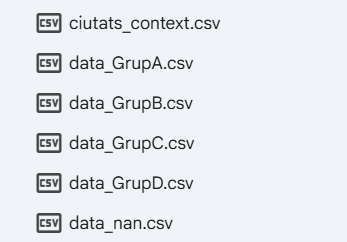

He tomado la decisión de crear un archivo con los valores vacios para que se puedan tener en cuenta. Si se hace un recuento, habrá una diferencia entre trabajadores totales y los que hay en los rchivos de cada grupo. De esta manera, se pueden tener en cuenta todos.

**» Crear y exportar un quinto DataFrame (en formato .csv o .xlsx)**

Este archivo deber contener, para cada grupo profesional
* Número total de empleados.
* Salario medio.
* Edad mediana.


In [126]:
resumen_grupos = (
    trabajadores.groupby("grup_professional")   # agrupamos por tipo de grupo para poder aplicar después las funciones agregadas que nos piden
      .agg(
          total_empleados=("nom","count"), # contamos el numero de empleados
          salario_medio=("salario_ajustado","mean"), # salario medio por grupo
          edad_mediana=("edad","median") # mediana de edad en cada grupo
      )
      .reset_index()
)

resumen_grupos.to_csv("resumen_grupos.csv",
               index=False)

Guardado correctamente:

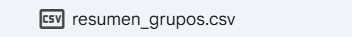

**EXTRA**

Explora cómo exportar todos los DataFrames a un único archivo de Excel, utilizando:

* Una pestaña para cada grupo profesional.
* Una pestaña adicional con el resumen agregado.


---

Utilizaremos ExcelWriter de la libreria Pandas. Además, como punto a favor,  nos permitirá en el futuro añadir datos a hojas ya existentes sin sobrescribir todo el documento cada vez que necesitemos actualizarlo.


In [ ]:
with pd.ExcelWriter("resultados.xlsx") as archivo:   # utilizamos ExcelWriter escribir varias hojas dentro del mismo archivo Excel, lo creamos como "archivo"

    for grupo in trabajadores["grup_professional"].unique():  #utilizamos el miso bucle de antes

        df_grupo = trabajadores[trabajadores["grup_professional"]==grupo]

        nombre = str(grupo).replace(" ", "")

        df_grupo.to_excel(
            archivo,
            sheet_name=nombre,
            index=False
        )

    resumen.to_excel(
        archivo,
        sheet_name="resumen",
        index=False
    )

Se ha creado correctamente:

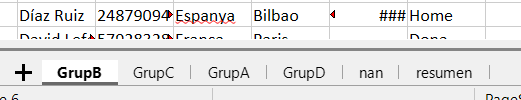

**» ¿Qué nivel de agrupación es el más adecuado para exportar los resultados?**

Desde mi puento de vista, es más adecuado o útil sería el grupo profesional.
Es una categoría dentro de la empresa de puede englobar diferentes cargos, salarios, géneros, etc.
Nos permite comparar diferentes tipo de trabajadores que comparten un mismo nivel o función, lo cual nos ayuda para un análisis salarial y la elaboración de informes más detallada, eficaz y fácil.

---

**» ¿Cómo separar los datos detallados de los datos agregados?**

En cada archivo o pestaña de tipo de grupo tendremos toda la información individual de cada trabajador y con esto podremos realizar análisis específicos. COmo hay un numero determinado de grupo, el excel o número de pestañas no será eterno.

Sin embargo, el resumen nos da la información principal de forma inmediata y sintetizada, mediante valores como el número de empleados, el salario medio y la edad mediana, siendo más útil para informes o presentaciones.

---

**» ¿Qué información es relevante para su uso posterior (análisis, visualización, elaboración de informes)?**

El *resumen*,  incluye únicamente las variables más representativas para comparar los grupos profesionales. En el resto de pestañas hay demasida información.

El importante conocer el número de empleados, para conocer el tamaño de cada grupo. Saber el salario medio, como medidor económico y la
edad mediana, para describir el perfil demográfico.

Esta separación entre datos detallados y datos agregados mejora la organización de la información y facilita su reutilización en análisis posteriores.


# **Nivel 3: EXPLORACIÓN VISUAL APLICADA Y OPTIMIZACIÓN**
## **Ejercicio 1: Exploración visual del conjunto de datos**

Crear una función que ayude a generar (y exportar) automáticamente un gráfico para cada columna del DataFrame. Por ejemplo, un histograma o un diagrama de caja si la variable es numérica, barras con los valores más frecuentes si es categórica, y barras con los años más frecuentes si los datos están en formato de fecha.

📌 Muestra el resultado de la función en uno de los conjuntos de datos de ejemplo incluidos en el paquete seaborn. Por ejemplo, iris, penguins o titanic.


---

Primero de todo importamos la librerias.

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [129]:
# Tal y como nos indica el enunciado, voy a cargar un df de ejmplo apra poder, después, testear la función.

penguins = sns.load_dataset("penguins")

# Muestro el df para ver qué datos hay, explorarlo y entender que es lo que necesito hacer.

display(penguins)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


· El DataFrame tiene 344 filas y 7 columnas.

· Es un conjunto de datos referente a pinguinos que nos muestra la *especie*, la *isla* donde habita, *tamaño del pico, *tamaño de aleta*, *peso*, *masa corporal* y *género*.

In [130]:
penguins.dtypes

,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object


· Hay 4 variables numéricas de tipo decimal.

In [131]:
penguins.groupby("species").count() # Hay 3 tipos de especies
penguins.groupby("island").count() # Hay 3 islas
penguins.groupby("sex").count()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
sex,,,,,,
Female,165,165,165,165,165,165
Male,168,168,168,168,168,168


Procedemos a crear la función que recibirá un DataFrame cualquiera:

In [132]:
def exportar_graficos(df):
  # recorrerá cada columna desde la primera (especie) a la última (género)..

  for columna in df.columns:


    # vamos a determinar si la columna es númerica o no (.is_numeric_dtype(col)). Si lo es --> True.
    if pd.api.types.is_numeric_dtype(df[columna]):

      plt.figure(figsize=(6,4)) # creamos un gráfico de 6 de ancho por 4 de largo

      plt.hist(                  # dibujamos un gráfico estadístico numérico con eje horizontal y vertical
          df[columna].dropna(),  # para que los valores nulos no genere errores en el gráfico.
          bins=15  # pongo 15 barras para que testear y poder ver los datos
      )

      plt.title(columna) # establecemos como título del gráfico el nombre de la columna

      plt.savefig(f"{columna}.png") # guardamos el gráfico con el nombre de la columna como .png

      plt.close()   # cerramos el bucle

# ahora vamos a determnar si la variable no es númerica, es decir, categórica (en este caso, especie, isla o género)

    elif pd.api.types.is_object_dtype(df[columna]):

# volvemos a hacer un gráfico de barra pero e este caso countaremos (count) cuantas veces aparece cada variable y hacemos lo mismo con el resto de código.
      plt.figure(figsize=(6,4))

      df[columna].value_counts().plot(
          kind="bar"
      )

      plt.title(columna)

      plt.savefig(f"{columna}.png")

      plt.close()

# tras haber revisado la función con el df "titanic" da un error, no habia tenido en cuentas el tipo bool asi que añado este código
    elif pd.api.types.is_bool_dtype(df[columna]):

      plt.figure(figsize=(6,4))

      df[columna].value_counts().plot(
                        kind="bar"
                    )

      plt.title(columna)

      plt.savefig(f"{columna}.png")

      plt.close()

# en este caso no tenemos fechas, pero la función debe ser válida para cualquier df, asi que debemos contemplar todas las opciones

    elif pd.api.types.is_datetime64_any_dtype(df[columna]):

      plt.figure(figsize=(6,4))

      df[columna].dt.year.value_counts().sort_index().plot(
          kind="bar"
      )

      plt.title(columna)

      plt.savefig(f"{columna}.png")

      plt.close()

In [133]:
exportar_graficos(penguins)

* Tenemos todos los gráficos, uno por columna, exportados

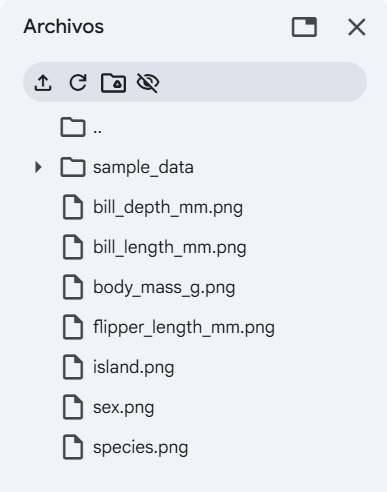

* ESPECIES (muestra de ejemplo)

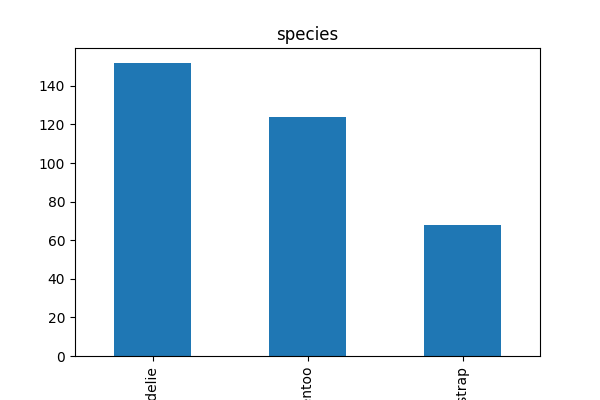

**DECISIÓN ANALÍTICA:**

La función que recorre automáticamente todas las columnas del DF y nos genera un gráfico adecuado según el tipo de dato.

He utilizado un histograma para las variables numéricas ya que me parece más claro que un *boxplot* (ejemplo abajo), me permite ver con mayor facilidad las diferencias y la distribución de los datos (números)

Para las variables categóricas creo que lo más correcto se usar un gráfico de barras con las cantidad de cada categoría para visualizar rápidamente los datos y la diferencia.

En el caso de variables de tipo fecha, agruparemos por año pero no podemos revisarlo con este dataframe "penguins".



---

*Ejemplo de diagrama de caja con una de las columnas.* ⬇


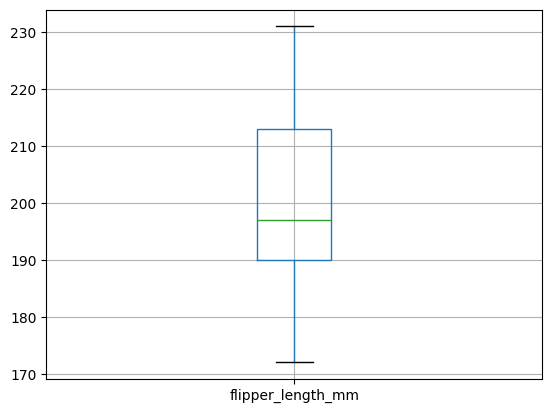

In [134]:
# Generamos un diaframa de caja (boxplot) solo para la columna "flipper_length_mm".
penguins.boxplot(column=["flipper_length_mm"])
plt.show()


SEGUNDA COMPROBACIÓN CON DF *IRIS*
Contiene información sobre flores.

In [135]:
iris = sns.load_dataset("iris")

In [136]:
display(iris)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [137]:
exportar_graficos(iris)

Se han creado y eportado los gráficos.

Ejemplo de "SPECIES*:

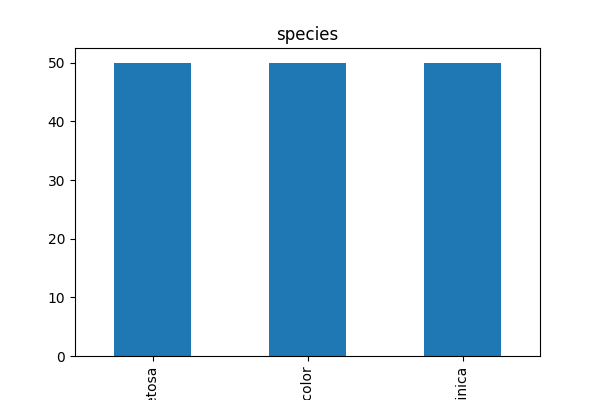

## **Ejercicio 2: Optimización de rutas (problema aplicado)**

» Trabajamos con una matriz de distancias entre ciudades.

» Se busca una solución sencilla, razonable y explicable.

» El objetivo no es encontrar la ruta óptima, sino una aproximación razonable.


---

**Desarrolla una función que:**

* Tome como argumentos: una ciudad de origen y una ciudad de destino.
* Devuelva: el orden de las ciudades visitadas (la ruta) y la distancia total recorrida.
* La ruta debe construirse utilizando una estrategia sencilla: dirigirse siempre a la ciudad más cercana que aún no se haya visitado hasta llegar al destino.


---



📌 Para crear está  función voy a desarrollar un sistema modular con las siguientes funciones:

1. Cargar el archivo
2. Transformar Dataframe
3. Validar las ciudades que se dan como argumentos. ¿Existen en el df?
4. Buscar la ciudad más cercana.
5. Calcular la distancia recorrida.
6. Mostrar la ruta

---

**FUNCIÓN cargar_matriz()**

Vamos a cargar el archivo.

In [138]:
def cargar_matriz():
  from google.colab import files

  archivo = files.upload()

  df = pd.read_excel(list(archivo.keys())[0])

  return df

In [139]:
# comprobamos
df_matriz = cargar_matriz()

Saving matriu_distancies.xlsx to matriu_distancies.xlsx


In [140]:
df_matriz

,Unnamed: 0,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Palma,Las Palmas de Gran Canaria,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
0,Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,206.0,2175.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
1,Valencia,303.0,NaN,541.0,246.0,468.0,177.0,260.0,1874.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
2,Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,791.0,1355.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
3,Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,377.0,2001.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
4,Málaga,770.0,468.0,158.0,628.0,NaN,323.0,695.0,1406.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
5,Murcia,471.0,177.0,433.0,408.0,323.0,NaN,372.0,1723.0,606.0,69.0,320.0,510.0,800.0,726.0,465.0
6,Palma,206.0,260.0,791.0,377.0,695.0,372.0,NaN,2093.0,621.0,303.0,671.0,664.0,1000.0,820.0,204.0
7,Las Palmas de Gran Canaria,2175.0,1874.0,1355.0,2001.0,1406.0,1723.0,2093.0,NaN,2022.0,1792.0,1470.0,1790.0,1682.0,1925.0,2168.0
8,Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,621.0,2022.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
9,Alicante,407.0,125.0,495.0,368.0,391.0,69.0,303.0,1792.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0


**FUNCIÓN transformar_matriz(df)**

* Vamos a establecer el índice correcto ➡ la primera columna será el index.
* Eliminamos el nombre/título del "index"
* Elimina *Las Palmas de Gran Canaria* y *Palma*


In [141]:
def transformar_matriz(df):
  df = df.set_index("Unnamed: 0") # establecemos nuevo index
  df.index.name = None     # eliminamos el nombre del index
  df = df.drop(index="Las Palmas de Gran Canaria", columns="Las Palmas de Gran Canaria")  # eliminamos la ciudad de ambos sitios (index y columna)
  df = df.drop(index="Palma", columns="Palma") # eliminamos la ciudad de ambos sitios (index y columna)

  return df

In [142]:
# comprobamos
df_ruta = transformar_matriz(df_matriz)

df_ruta

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0
Valladolid,576.0,441.0,486.0,320.0,549.0,510.0,232.0,515.0,419.0,NaN,337.0,224.0,570.0


**CONCLUSIÓN:** Entiendo que se pide eliminar estas 2 ciudades porque no son accesibles para una ruta en coche ➡ SON ISLAS.


---

**FUNCIÓN validar_ciudades**
* Toma como argumento las 2 ciudades (origen y destino)
* Si una de las ciudades no existe, dará e imprimirá el error.

In [143]:
def validar_ciudades(origen, destino, df):
  # Comprobamos la ciudad de origen
  if origen not in df.index:
      raise ValueError("La ciudad de origen no existe.")

  # Comprobamos la ciudad de destino
  if destino not in df.index:
      raise ValueError("La ciudad de destino no existe.")

In [144]:
#comprobamos
validar_ciudades("Madrid", "Barcelona", df_ruta)  # Madrid no está en el df


ValueError: La ciudad de origen no existe.

In [145]:

validar_ciudades("Vigo", "Barcelona", df_ruta) # Vigo si existe


In [146]:
validar_ciudades("Barcelona", "Madrid", df_ruta)

ValueError: La ciudad de destino no existe.

**FUNCIÓN ciudades_cercanas()**

Ahora necesitamos una función que, dada una ciudad y un conjunto de ciudades ya visitadas, encuentre la más cercana no visitada

Toma como argumentos la ciudad en la que la ruta está, el df y una lista de ciudades visitas.

In [147]:
def ciudad_mas_cercana(df, ciudad_actual, visitadas):

  distancias = df.loc[ciudad_actual].drop(labels=visitadas, errors="ignore")  # quitamos las ya visitadas
  distancias = distancias.dropna()  # quitamos NaN (por si queda alguno)

  ciudad_siguiente = distancias.idxmin()   # ciudad con distancia mínima
  distancia_siguiente = distancias.min()   # esa distancia mínima

  return ciudad_siguiente, distancia_siguiente

In [148]:
#comprobamos con 2 ciudades aleatorias
ciudad_mas_cercana(df_ruta, "Vigo", "Gijón") # la ciudad mas cercana a Vigo es Gijón, como ya está como argumento, pasa a la siguiente


('Valladolid', 337.0)

**FUNCIÓN construir ruta**

Una función que toma como argumentos el df, la ciudad de origen y la ciudad de destino. Debe añadir cada ciduad a la ruta (lista) siempre y cuando no exista ya en la lista.

In [149]:
def construir_ruta(df, origen, destino):

  ruta = [origen]  # crear la ruta
  visitadas = {origen}   # crear el conjunto de ciudades visitadas, un set no permite valores repetidos, asi que lo utilizamos
  distancia_total = 0  # creamos un contador al que iremos sumando los km entre las ciudades recorridas
  ciudad_actual = origen

# conforme vayamos avanzando, siempre que la ciudad sea distinta al destino, seguiremos
  while ciudad_actual != destino:
    siguiente, distancia = ciudad_mas_cercana(df, ciudad_actual, visitadas)  # buscamos la ciudad mas cercana, nos dará la distancia y la ciudad

    ruta.append(siguiente)  # añadimos la siguiente ciudad que encontremos a la lsita de la ruta
    visitadas.add(siguiente)   # añadimos la siguiente ciudad que encontremos al set de la ruta
    distancia_total += distancia  # sumamos la distancia de esa ciudad al contador
    ciudad_actual = siguiente #establecemos de nuevo la ciudad actual y continua el bucle

  return ruta, distancia_total

In [150]:
# comprobamos la función

ruta = construir_ruta(df_ruta, "Vigo", "Sevilla")

print(ruta)

(['Vigo', 'Gijón', 'Bilbao', 'Valladolid', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla'], 1945.0)


**FUNCIÓN mostrar la ruta**

* Toma como argumento la lista que ya hemos creado con la ruta en la función anterior y el df.
* Mostramos la ruta de forma ordenada, indicando el orden de la ciudad, la ciudad y la distancia que vamos recorriendo.

In [151]:
def mostrar_ruta(ruta, df):
  distancia_acumulada = 0

  print("***********************************************************************")
  print(f"  RUTA: {ruta[0]} → {ruta[-1]}")
  print("***********************************************************************")

# quiero que imprima el orden de la ciudad en la ruta, como el índice empieza en 0, le digo que empiece en 1, la ciudad de origen será 1, por ejemplo
  for i, ciudad in enumerate(ruta):
    print(f"  [{i + 1}] {ciudad}")

    if i < len(ruta) - 1:  # de nuevo, como el indice empieza por 0 necesitamos que cuente el numeor de elementos de la lista
      siguiente = ruta[i + 1]
      distancia_tramo = df.loc[ciudad, siguiente]  # buscamos la distancia
      distancia_acumulada += distancia_tramo # sumamos al contados la anterior distancia
      print(f"         │")    # estético
      print(f"      {distancia_tramo:.0f} km")  # mostramos la distancia entre una ciudad y otra
      print(f"         │")

  print("***********************************************************************")
  print(f"  DISTANCIA TOTAL: {distancia_acumulada} km")
  print("***********************************************************************")


**FUNCIÓN PRINCIPAL calcular_ruta()**

Ejecutamos las funciones anteriores una a una:

1. Cargamos el archivo
2. Lo limpiamos y transformamos
3. Validamos que las ciudades existan.
4. Creamos la ruta ordenada
5. Mostramos la ruta
6. Guardamos la ruta

In [152]:
def calcular_ruta(origen, destino):
  try:
    df = cargar_matriz()
    df1 = transformar_matriz(df)



    ruta, distancia_total = construir_ruta(df1, origen, destino)

    mostrar_ruta(ruta, df1)

    return ruta, distancia_total

  except Exception as e:
    print("Error:", e)

In [154]:
# Comprobamos con ciudades existentes
calcular_ruta("Vigo", "Barcelona")

Saving matriu_distancies.xlsx to matriu_distancies (2).xlsx
***********************************************************************
  RUTA: Vigo → Barcelona
***********************************************************************
  [1] Vigo
         │
      289 km
         │
  [2] Gijón
         │
      223 km
         │
  [3] Bilbao
         │
      232 km
         │
  [4] Valladolid
         │
      320 km
         │
  [5] Zaragoza
         │
      246 km
         │
  [6] Valencia
         │
      125 km
         │
  [7] Alicante
         │
      69 km
         │
  [8] Murcia
         │
      320 km
         │
  [9] Córdoba
         │
      121 km
         │
  [10] Sevilla
         │
      158 km
         │
  [11] Málaga
         │
      763 km
         │
  [12] Hospitalet de Llobregat
         │
      7 km
         │
  [13] Barcelona
***********************************************************************
  DISTANCIA TOTAL: 2873.0 km
***************************************************

(['Vigo',
  'Gijón',
  'Bilbao',
  'Valladolid',
  'Zaragoza',
  'Valencia',
  'Alicante',
  'Murcia',
  'Córdoba',
  'Sevilla',
  'Málaga',
  'Hospitalet de Llobregat',
  'Barcelona'],
 2873.0)

In [155]:
# Comprobamos con ciudades NO existentes
calcular_ruta("Madrid", "Barcelona")

Saving matriu_distancies.xlsx to matriu_distancies (3).xlsx
Error: 'Madrid'


# **SILVIA VILCHES**

## SPRINT 8



---



### ¡GRACIAS!
